# 7. Reject Invalid Subscriber #2

## 7.1. Confirmation Email

### 7.1.0 Overview

Main reason we prioritize sending our newsletter subscribers a confirmation email, is because we want explicit consent for the
subscribers that we can send them newletter issues. This allows us to;
1. Shield our users from abuse (EU mandates explicit consent from the user for example)
2. We get to confirm that the email addresses they provided actually exist before trying to send them a newsletter

### 7.1.1. The Confirmation User Journey

Every time a user want to subscribe to our newsletter they fire a `POST /subscriptions` request. Our request handler will
- Add their details to our database in the `subscriptions` table, with `statux` equal to `pending_confirmation`
- generate (unique) `subscription_token`;
- store `subscription_token` in our database against their `id` in a `subscription_tokens` table;
- send an email to the new subscriber containing a link structured as `https:://<api-domain>/subscriptions/confirm?token=<subscription_token>`;
- return a `200 OK`

Once a user clicks on the link, a browser tab will open up and `GET` request will be fired to our `GET /subscription/confirm` endpoint. Our request
handler will:
- retrieve `subscription_token` from the query parameters
- retrieve the subscriber `id` associated with the `subscription_token` from the `subscriptions_token` table;
- update the subscriber status from `pending_confirmation` to active in the `subscriptions` table;
- return a `200 OK`.

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px;">

<h5>Note:</h5>
    
There are a few other possible designs/approaches (e.g. use a JWT instead of a unique token) and we have a few edge/corner cases to handle e.g.
- What happens if they click on the link twice?
- What happends if they try to subscribe twice?

We will discuss both at the most appropriate time as we make progress with the implementation.

</div>

The implementation strategy
1. Write a module to send an email
2. adapt the logic of our existing `POST /subscriptions` request handler to match new specifications
3. write a `GET /subscriptions/confirm` request handler from scratch.

## 7.2. EmailClient, Our Email Delivery Component

### 7.2.1. How to Send An Email

#### 7.2.1.0. Overview

How do we _actually_ send an email?

How does it work?

We have to look into **SMTP**
> **S**imple **M**ail **T**ransfer **P**rotocol
>
> Its been around since the early days of the internet - the first RFC dates back to 1982.
>

SMTP does for emails what HTTP does for web pages:
> it is an application-level protocol that ensures that different implementations of email servers and clients can understand each other and
> exchange messages.

We will not be building our own private email server, it will take too long and we wouldn't gain much from the effort. We will be leveraging a
third-party service.

Do we need to talk SMTP to these third party services?

Not necessarily.

SMTP is a specialised protocol. Learning a new protocol takes time and we are bound to make mistakes along the way - that is why most providers
provide two interfaces: SMTP and REST API

If we were familiar with the email protocol, or we needed some non-conventional configuration, we would use the SMTP interface. Otherwise we will
get up and running much faster and more reliably using a REST API

#### 7.2.1.1. Choosing an Email API

For our implementation we will work with 
- [Postmark](https://account.postmarkapp.com/servers) - for following along with the book (need a work email with private domain)
- [MailJet](https://app.mailjet.com/onboarding) - a Postmark alternative (Works with public domains [gmail, yahoo] for now)

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px;">


<h4>Note:</h4>
    
We had a challenge setting up **DKIM** and **Return-Path** verification for our [hai-hub.com](hai-hub.com) domain because we were adding the Postmark DNS records
to squarespace which where we have registered our domain but our DNS records are managed else where (_Netlify_). Adding the DNS records on netlify resolved 
the issue.

</div>

#### 7.2.1.2. The Email Client Interface

There are usually two approaches when it comes to a new piece of functionality
1. Bottom-Up - starting from the implementation details and slowly working our way up
2. Top-Down - designing the interface first and then figuring out how the implementation is going to work (to an extent).

In this case, we will go for the second route.

What kind of interface do we want for our email client?

We'd like to have some kind of `send_email` method. At the moment we just need to send a single email out at a time - we will deal
with the complexity of sending emails in batches when we start working on newsletter issues.

What arguments should `send_email` accept?

We will definitely need;
- recipient email address,
- the subject line,
- email contents
    - We'll ask for both HTML and plain versions of the email content
- sender email address? We'll assume that all emails sent by an instance of the client are coming from the same address, therefore we
  do not need it as an argument of `send_email`, it will be one of the arguments in the constructor of the client itself.

We will also expect `send_email` to be an asynchronous function, given that we will be performing I/O to talk to a remote server.

Stiching everything together, we have something that looks more or less like this:

```Rust
//! src/email_client.rs

use crate::domain::SubscriberEmail;

pub struct EmailClient {
    sender: SubscriberEmail;
}

impl EmailClient {
    pub async fn send_email(
        &self,
        _recipient: SubscriberEmail,
        _subject: &str,
        _html_content: &str,
        _text_content: &str,
    ) -> Result<(), String>
    {
        todo!("NOT YET IMPLEMENTED")
        
    }
}


//! src/lib.rs

pub mod configuration;
pub mod domain;
// New entry!
pub mod email_client;
pub mod routes;
pub mod startup;
pub mod telemetry;
```

There is an unresolved question - the return type. We sketched a `Result<(), String>` which is a way to spell _"I'll think about error handling later"_.

### 7.2.2. How To Write A REST Client Using `reqwest`

#### 7.2.2.0. Overview

To talk with a REST API we need a HTTP client.

We will go with the most popular option on crates.io: [reqwest](https://crates.io/crates/reqwest)

What to say about [reqwest](https://crates.io/crates/reqwest)
- It has been exhaustively battle-tested (~450 million downloads as of this writing)
- It offers a primarily asynchronous interface, with the option to enable a synchronous one via the blocking feature flag.
- It relies on tokio as its asynchronous executor, matching what we are already using due to `actix-web`;
- It does not depend on any system library if we only choose `rustls` to back the TLS implementation (`rustls` feature flag)
  making it extremely portable

And we are already using `reqwest` in our intergration tests. Let's lift it from a development dependency to a runtime
dependency.

```toml
#! Cargo.toml
#  [...]

[dependencies]
# We need the `json` feature flag to serialize/deserialize JSON payloads
reqwest = {version = "0.13", features = ["json", "rustls"]}

[dev-dependencies]
# Remove `reqwest`'s entry from this list
# [...]
```

#### 7.2.2.1. `reqwest::Client`

The main type we will be dealing with when working with `reqwest` is `reqwest::Client` - it exposes all the methods we need to
perform requests against a REST API.

We will use `Client::new` to get a new client instance although we could have also used `Client::builder` if we needed to tune
the default configuration.

We add two fields to `EmailClient`:
- `http_client`, to store a `Client` instance
- `base_url`, to store the URL of the API we'll be making requests to

```Rust
//! src/email_client.rs

use crate::domain::SubscriberEmail;

pub struct EmailClient {
    http_client: reqwest::Client,
    base_url: String,
    sender: SubscriberEmail,
}

impl EmailClient {
    pub fn new(
        base_url: String, 
        sender: SubscriberEmail,
    ) -> Self
    {
        Self {
            http_client: Client::new(),
            base_url,
            sender
        }
    }

    // [...]
}
```

#### 7.2.2.2. Connection Pooling

Before executing a HTTP request against an API hosted on a remote server we need to establish a connection.

It turns out that connecting is a fairly expensive operation, even more so if using HTTPS:
> creating a brand-new connection every time we need to fire off a request can impact the performace of our application and
> might lead to a problem known as _**socket exhaustion**_ under load.

To mitigate the issue, most HTTP clients offer _connection pooling_:
> after the first request to a remote server has been completed, they will keep the connection open (for a certain amout of
> time) and re-use it if we need to fire off another request to the same server, therefore avoiding the need to re-establish
> a connection from scratch.

`reqwest` is not different- every time a `Client` instance is created `reqwest` initialises a connection pool under the hood.

To leverage this connection pool we need to **re-use the same Client** across multiple requests.

> It is worth noting that `Client::clone` does not create a new connection pool - we just clone a _pointer_ to the underlying
> pool

#### 7.2.2.3. How to Reuse The Same `reqwest::Client` In `actix-web`

To re-use the same HTTP client acros multiple requests in `actix-web` we need to store a copy of it in the application context -
we will then be able to retrieve a reference to `Client` in our request handlers using an extractor (e.g.
`actix_web::web::Data`)

To pool this off we have 2 options
- derive the `Clone` trait for `EmailClient`, build an instance of it once and then pass a cline to `app_data` everytime we need
 to build an App:
  
     >  ```Rust
     > //! src/email.rs
     > #[derive(Clone)]
     > pub struct EmailClient {
     >    http_client: reqwest::Client,
     >    base_url: String,
     >    sender_email: SubscriberEmail,
     > }
     > // [...]
     > ``` 
       
     > ```Rust 
     > //! src/startup.rs
     > use crate::email_client::EmailClient
     > // [...]
     > 
     > pub fn run(
     >     listener: TcpListener,    
     >     db_pool: PgPool,    
     >     email_client: EmailClient,    
     > ) -> Result<Server, std::io::Error> {
     >    let db_pool = Data::new(db_pool);
     >    let server = HttpServer::new( move || {
     >        App::new()
     >            .wrap(TracingLogger::default()) 
     >            .route("/health_check", web::get().to(health_check))          
     >            .route("/subscriptions", web::post().to(subscribe))          
     >            .app_data(db_pool.clone())
     >            .app_data(email_client.clone())
     >   }) 
     >   .listener(listener)?
     >   .run();
     >
     >   Ok(server) 
     > }
     > 
     > ```
 - wrap `EmailClient` in `actix_web::web::Data` (an `Arc` pointer) and pass a pointer to `app_data` every time we need to build
   an App - like we are doing with `PgPool`;
    > ```Rust 
     > //! src/startup.rs
     > use crate::email_client::EmailClient
     > // [...]
     > 
     > pub fn run(
     >     listener: TcpListener,    
     >     db_pool: PgPool,    
     >     email_client: EmailClient, // New param   
     > ) -> Result<Server, std::io::Error> {
     >    let db_pool = Data::new(db_pool);
     >    let email_client = Data::new(email_client);
     >    let server = HttpServer::new( move || {
     >        App::new()
     >            .wrap(TracingLogger::default()) 
     >            .route("/health_check", web::get().to(health_check))          
     >            .route("/subscriptions", web::post().to(subscribe))          
     >            .app_data(db_pool.clone())
     >            .app_data(email_client.clone())
     >   }) 
     >   .listener(listener)?
     >   .run();
     >
     >   Ok(server) 
     > }
     > 
     > ```

Which way is best?

If `EmailClient` were just a wraper around a `Client` instance, the first option would be preferable - we avoid wrapping the 
connection pool twice with `Arc`.

This is not the case though: `EmailClient` has two data fields attached
- `base_url`
- `sender`

The first implementation (`Clone`) allocates new memory to hold a copy of that data every time an App instance is created, while
the second shares it among all App instances.

Beware though, we are creating an App instance for each thread - the cose of a string allocation (or a pointer clone) is 
negligible when looking at the bigger picture.

We are going through the decision-making process here as an exercise to understand the tradeoffs - we might have to make a 
similar call in the future where the cost of the two options is remarkably different.

#### 7.2.2.4. Configuring Our `EmailClient`.

Running `cargo check`, will get us the error below

```bash
error[E0061]: this function takes 3 arguments but 2 arguments were supplied
--> src/main.rs:24:5
|
24 | run(listener, connection_pool)?.await?;
| ^^^ -------- --------------- supplied 2 arguments
| |
| expected 3 arguments
error: aborting due to previous error
```

Looking at our `src/main.rs` it is clear that we have not added the `email_client` argument to the `run` call below

```Rust
//! src/main.rs
// [...]

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    // [...]
    run(listener, connecton_pool)?.await?;
    Ok(())
}
```

We are building the dependencies of our application (address & db) using the values specified in the configuration we retrieved
via `get_configuration`.

To build an `EmailClient` instance we need the base URL of the API we want to fire requests to and the sender email address 
<span>&mdash;</span> let's add them to our `Settings` struct:

```Rust
//! src/config.rs
// [...]

use crate::domain::SubscribeEmail;

#[derive(serde::Deserialize)]
pub struct Settings {
    pub db: DBSettings,
    pub app: AppSettings,
    pub email_client_settings: EmailClientSettings, // New field
}

#[derive(serde::Deserialze)]
pub struct EmailClientSettings {
    pub base_url: String,
    pub sender_email: String,
}

impl EmailClientSettings {
    pub fn sender(&self) -> Result<SubscriberEmail, String> {
        SubscriberEmail::parse(self.sender_email.clone())
    }
}

// [...]
```

We need to set values for the in our configuratoin files

```yaml
#! configuration/base.yaml
app:
    # [...]
db:
    # [...]
email_client_settings:
    base_url: "localhost"
    sender_email: "test@gmail.com"
```

```yaml
#! configuration/production.yaml
app:
    # [...]
db:
    # [...]
email_client_settings:
    # Value retrieved from Postmark's API documentation
    base_url: "https:://api.postmarkapp.com"
    # Use the single sender email ww authorised on Postmark!
    sender_email: "test@gmail.com"
```

We can now build an `EmailClient` instance in `main` and pass it to the `run` function

```Rust
//! src/main.rs
// [...]
use zero2prod::email_client::EmailClient;

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    // [...]
    let configuration = get_configuration().expect("Failed to read configuration");
    let connection_pool = PgPoolOptions::new()
        .connect_lazy_with(configuration.db.connect_options());

    // Build an `EmailClient` using `configuration`
    let sender_email = configuration.email_client_settings.sender()
        .expect("Invalid sender email address.");

    let email_client = EmailClient::new(
        configuration.email_client_settings.base_url,
        sender_email,
    );

    let address = format!(
        "{}:{}",
        configuration.app.host, configuration.app.port
    );

    let listener = TcpListener::bind(address)?;
   // Adding new argument `email_client`  to `run`
    run(listener, connecton_pool)?.await?;
    Ok(())
}
```

`cargo check` should now pass, although there are a few warnings about unused variables, which we'll get to.

`cargo check --all-targets` returns an error similar to the one we've just addressed for the `run` function in our intergration
tests.

```bash
error[E0061]: this function takes 3 arguments but 2 arguments were supplied
--> tests/health_check.rs:36:18
|
36 | let server = run(listener, connection_pool.clone())
| ^^^ -------- ----------------------- supplied 2 arguments
| |
| expected 3 arguments
error: aborting due to previous error
```

We do have some code duplication that we need to address but let's patch it quickly for now for our code to compile.

```Rust
//! tests/health_check.rs

// [...]
use zero2prod::email_client::EmailClient;
// [...]

async fn spawn_app() -> TestApp {
    // [...]
    let mut configuration = get_configuration()
        .expect("Failed to read configuration");
    configuration.db.db_name = Uuid::now_v7().to_string();
    let conection_pool = configure_db(&configuration.database).await;

    // Bulld a new email client
    let sender_email = configuration.email_client_settings.sender()
        .expect("Invalid email address");
    let email_client = EmailClient::new(
        configuration.email_client_settings.base_url,
        sender_email,
    );

    // Pass hte new client to `run`
    let server = run(listener, connection_pool.clone(), email_client)
        .expect("Failed to bind address");

    let _ = tokio::spawn(server);

    TestApp {
        address,
        db_pool: connection_pool,
    }
}
```

`cargo test` should succeed now.

#### 7.2.2.5. Re-use: Axum implementation

For our axum implementation. The biggest difference is on how we re-use our `EmailClient` and `PgPool` instances. 

We make use of an `AppState` struct that wraps both `PgPool` and `EmailClient` as follows.
```Rust
//! src/startup.rs
// [...]

#[derive(Clone)]
pub struct AppState {
    pub db_pool: PgPool
    pub email_client: Arc<EmailClient>,
}

pub async run(
    listener: TcpListener,
    db_pool: PgPool,
    email_client: EmailClient,
) -> Result<(), std::io::Error> {
    // [...]
    let state = AppState {
        db_pool,
        email_client: Arc::new(email_client),
    }
    let app = Router::new()
                .route("/health_check", get(health_check))
                .route("/subscriptions", post(subscribe))
                .layer(tracing_layer)
                .with_state(state); // Passing state
}
```

Note how we instatiate `email_client` with `Arc::new()`. This allows us to re-use `email_client` without cloning in a thread safe manner.

The rest of the implementation looks similar to the Actix implementation with one exception. The `subscribe` function. Since now we are using `AppState` we need to update the `subscribe` function route to take in a state instead of the `db_pool` only as shown below.

```Rust
//! src/routes/subscriptions.rs
// [...]
#[tracing::instrument(
    name = "Adding a new subscriber",
    skip(state, form), // Updated to use `state` instead of `db_pool
    fields (
        subscriber_email = &form.email,
        subscriber_username = &form.username,
    )
)]
pub async fn subscribe(
    State(state): State<AppState>, // Updated from `State(db_pool): State<PgPool>`
    Form(form): Form<FormData>,
) -> impl IntoResponse {
    // [...]
    
    // We update `insert_subscriber` argument  as well
    match insert_subscriber(&state.db_pool, &new_subscriber).await {
        // [...]
    }
}
```

### 7.2.3. How to Test A REST Client Using `reqwest`

#### 7.2.3.0. Overview

Staying true to T.D.D. its time to write a test!

We could start from our integration tests: change the ones for `POST /subscriptions` to make sure that the endpoint conforms to our new requirements.

It would take us a long time to turn them green through: apart from sending an email, we need to add logic to generate a unique token and store it.

We start smaller: we will just test our `EmailClient` component in isolation.<br>
It will boost our confidence that it behaves as expected when tested as a _unit_, reducing the number of issues we might encounter when integrating it
into the larger confirmation email flow.<br>
It will also give us a chance to see if the interface we landed on is ergonomic and easy to test.

What should we actually test though?<br>
The main purpose of our `EmailClient::send_email` is to perform a HTTP call:<br>
- How would we know it happened?
- How do we check that the body and the headers were populated as we expected?

We need to _intercept_ that HTTP request <span>&mdash;</span> time to spin up a mock server!

#### 7.2.3.1. HTTP Mocking With `wiremock`

We add a test module at the bottom of `src/email_client.rs`. We do not know enough about Postmark to make assertions about what we should
see in the outgoing HTTP request.<br>
Nonetheless, it is reasonable to expect a request to be fired to the server at `EmailClient::base_url`. We add `wiremock` to our development
dependencies with `cargo add --dev wiremock`.

Using `wiremock`, we can write a test `send_email_fires_a_request_to_base_url` as follows:

```Rust
//! src/email_client.rs
// [..]

#[cfg(test)]
mod tests {
    use crate::domain::SubscriberEmail;
    use crate::email_client::EmailClient;
    use fake::faker::internet::en::SafeEmail;
    use fake::faker::lorem::en::{Paragraph, Sentence};
    use fake::{Fake, Faker};
    use wiremock::matchers::any;
    use wiremock::{Mock, MockServer, ResponseTemplate};

    #[tokio::test]
    async fn send_email_fires_a_request_to_base_url() {
        // Arange
        let mock_server = MockServer::start().await;
        let sender = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
        let email_client = EmailClient::new(mock_server.uri(), sender);

        Mock::given(any())
            .respond_with(ResponseTemplate::new(200))
            .expect(1)
            .mount(&mock_server)
            .await;

        let subscriber_email = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
        let subject: String = Sentence(1..2).fake();
        let content: String = Paragraph(1..10).fake(); 

        // Act
        let _ = email_client
            .send_email(subscriber_email, &subject, &content, &content)
            .await;

        // Assert
    }
    
}
```

Let's break down what's happening, step by step.

#### 7.2.3.2. `wiremock::MockServer`

```Rust
let mock_server = MockServer::start().await;
```

`wiremock::MockServer` is a full-blown HTTP server.<br>
`MockServer::start` asks the operating system for a random available port and spings up the server on a back-ground thread, ready to listen for incoming
requests.

How do we point our email client to our mock server?<br>
We can retreive the address of the mock server using the `MockServer::uri` method; we can then pass it 
as the `base_url` to `EmailClient::new` as in the line

```Rust
let email_client = EmailClient::new(mock_server.uri(), sender);
```

#### 7.2.3.3. `wiremock::Mock`

Out of the box, `wiremock::MockServer` returns `404 Not Found` to all incoming requests.<br>
We can instruct the mock server to behave differently by mounting a `Mock`.

```Rust
Mock::give(any())
    .respond_with(ResponseTemplate::new(200))
    .expect(1)
    .mount(&mock_server)
    .await;
```

When `wiremock::MockServer` receives a request, it iterates over all the mounted mocks to check if the request _matches_ their conditions.<br>
The matching conditions for a mock are specified using `Mock::given`.

We are passing `any()` to `Mock::Given` which, according to `wiremock`'s documentation.

<div style="background: #313B51; color: white; padding: 15px; border-radius: 15px; border: 2px solid white;">

Match all incoming requests, regardless of their method, path, headers or body. You can use it to verify that a request has been fired towards the server, without
making any other assertion about it
    
</div>

Basically, it always matches, regardless of the request - which is want we want here.

When an incoming request matches the condition of a mounted mock, `wiremock::MockServer` returns a response following what was specified in `respond_with`. We passed
`ResponseTemplate::new(200)` - a `200 Ok` response without a body.

A `wiremock::Mock` becomes effective only after it has been mounted on a `wiremock::Mockserver` - that's what our call to `Mock::mount` is about.

#### 7.2.3.4. The Intent Of A Test Should Be Clear

We then have the actual invocation of `EmailClient::send_email`:

```Rust
let subscriber_email = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
let subject: String = Sentence(1..3).fake();
let contents: String = Paragraph(1..10).fake();

// Act
let _ = email_client.send_email(subscriber_email, &subject, &contents, &contents).await;
```

Notice that we are leaning heavily on `fake` here: we are generating random data for all the inputs to `send_email`.<br>
We could have just hard-coded a bunch of values, why did we choose to go all the way and make them random?

A reader, skimming the test code should be able to identify easily the property that we are trying to test. Using random data conveys a specific message:
> _do not pay attention to these inputs, their values do not influence the outcome of the test, that's why they are random!_

Hard-coded values instead, should always give us pause: does it matter that `subscriber_email` is set to `"marco@gmail.com"`? Should the test pass if I set it
to another value? In a test like ours, the answer is obvious. In a more intricate setup, it often isn't.

#### 7.2.3.5. Mock expectations

The end of the test looks a bit cryptic: there is an `// Assert` comment... but no assertion afterwards. Let's go back to our `Mock` setup line:
```Rust
Mock::given(any())
    .respond_with(ResponseTemplate::new(200))
    .expect(1)
    .mount(&mock_server)
    .await;
```


What does `.expect(1)` do?<br>
It sents an _expectation_ on our mock; we are telling the mock server that during this test it should receive _exactly_ one request that matches the
conditions set by this mock.<br>
We could also use ranges for our expectations - e.g. `expect(1..)` if we want to see _at least_ one request, `expect(1..=3)` if we expect at least one
request but no more than three, etc.

Expectations are verified when `MockServer` goes out of scope - at the end of our test function. Before shutting down, `MockServer` will iterate over 
all the mounted mocks and check if their expectations have been verified. If the verification step fails, it will trigger a panic and fail the test.

In our case running `cargo -test` results in the error below.

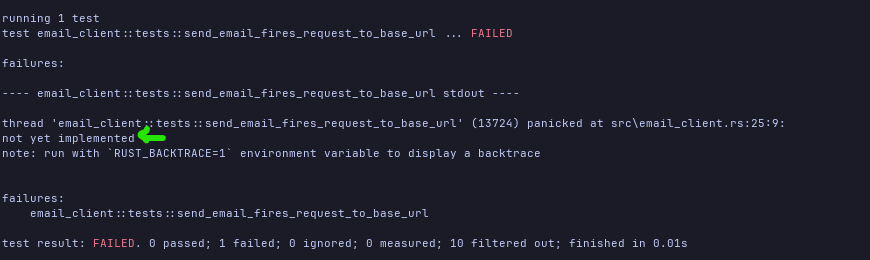

Our `todo!()` placeholder in `send_email`'s body causes our test to fail.

Let's replace it with a dummy `Ok`

```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]

    pub async fn send_email(
        recipient_email: SubscriberEmail,
        subject: &st,
        html_content: &str,
        txt_content: &str, 
    ) -> Result<(), String> {
        // No matter the input.
        Ok(())
    }
}
// [...]
```

Running the test again, we'll get to see `wiremock` in action

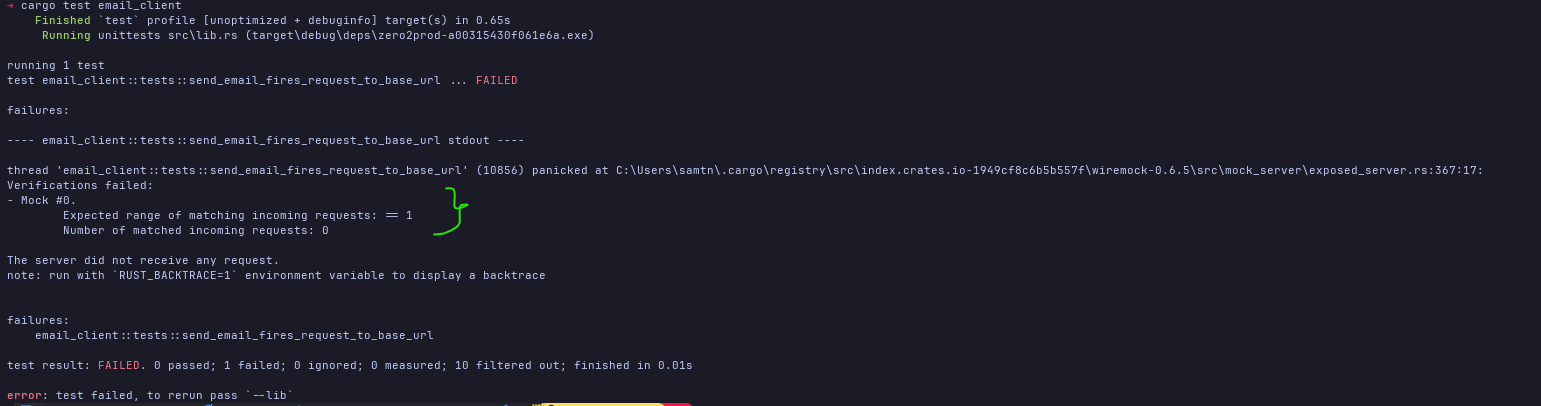
The server expected one request, but it received none - therefore the test failed.

We now need to flesh out `EmailClient::send_email` properly.

### 7.2.4. First Sketch Of `EmailClient::send_email`

#### 7.2.4.0. Overview

Let's take a look at Postmark's API documentation for ["Send a single email"](https://postmarkapp.com/developer/api/email-api)

The example request with `curl` looks like this:
```bash
curl "https://api.postmarkapp.com/email" \
    -X POST \
    - H "Accept: application/json" \
    - H "Content-Type: application/json" \
    - H "X-Postmark-Server-Token: server token" \
    - d '{
        "From": "sender@example.com",
        "To": "sender@example.com",
        "Subject": "Postmark test",
        "TextBody": "Hello dear Postmark user",
        "HtmlBody": "<html><body><strong>Hello</strong> dear Postmark user.</body></html>",
        "MessageStream": "outbound",
    }'
```

Let's break it down - to send an email we need:
- a `POST` request to the `/email` endpoint;
- a `JSON` body, with fields that map closely to the arguments of `send_email`. We need to be careful with fields names, they must be pascal cased.
- an authorization header, `X-Postmark-Server-Token`, with a value set to a secret token that we can retrieve from their portal.


If the request succeeds, we get a response like this back:
```bash
HTTP/1.1 200 OK
Content-Type: application/json

[
  {
    "ErrorCode": 0,
    "Message": "OK",
    "MessageID": "b7bc2f4a-e38e-4336-af7d-e6c392c2f817",
    "SubmittedAt": "2010-11-26T12:01:05.1794748-05:00",
    "To": "receiver1@example.com"
  },
  {
    "ErrorCode": 406,
    "Message": "You tried to send to a recipient that has been marked as inactive. Found inactive addresses: example@example.com. Inactive recipients are ones that have generated a hard bounce, a spam complaint, or a manual suppression. "
  }
]
```

We have enough to implement the happy path.

#### 7.2.4.1. `reqwest::Client::post`

`reqwest::Client` exposes a `post` method - it takes the URL we want to call with a `POST` request as argument and it returns a `RequestBuilder`.

`RequestBuilder` gives us a fluent API to build out the rest of the request we want to send, piece by piece.

```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]
    pub async fn send_email(
        &self,
        recipient_email: &str,
        subject: &str,
        html_content: &str,
        txt_conten: &str,
    ) {
        // We can do better using `reqwest::Url::join` if we change
        // `base_url`'s type from `String` to `reqwest::Url`.
        // We'll do on for the axum implementaiton
        let req_url = format!("{}/email", self.base_url);
        let req_builder = self.http_client.post(&req_url);
        Ok(())
    }
}
```

#### 7.2.4.2. JSON body

We can encode the request body schema as a struct:

```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]
    pub async fn send_email(
        &self,
        recipient_email: &str,
        subject: &str,
        html_content: &str,
        txt_conten: &str,
    ) {
        let req_url = format!("{}/email", self.base_url);
        let req_body = SendEmailRequest {
            from: self.sender_email.as_ref().to_owned(),
            to: recipient_email.as_ref().to_owned(),
            subject: subject.to_owned(),
            html_body: html_content.to_owned(),
            txt_body: txt_body.to_owned(),
        };
        let req_builder = self.http_client
            .post(&req_url)
            .json(&req_body);
            
        Ok(())
    }
}

#[derive(serde::Serialize)]
struct SendEmailRequest {
    from: String,
    to: String,
    subject: String,
    html_body: String,
    txt_body: String,
}
```

Updating the `src/email_client.rs` with the above should compile.<br>
The `json` call we chain to `post` goes a bit further than simple serialization: it will also set the `Content-Type` header to `application/json` matching
what we saw in the example.

#### 7.2.4.3. Authorization Token

Next we need to add an authorization header, `X-Postmark-Server-Token`, to the request. Just like the `sender_email` we need to store the token value as a
field in `EmailClient`.

We update `EmailClient::new` and `EmailClientSettings` as follows:

```Rust
//! src/email_client.rs
use secrecy::Secret;
// [...]
pub struct EmailClient {
    // [...]
    authorization_token: SecretString,
}

impl EmailClient {
    pub fn new (
        // [...]
        authorization_token: SecretString,
    ) -> Self {
        Self {
            // [...]

            authorization_token,
        }
    }
}

//! src/config.rs
// [...]

#[derive(serde::Deserialize)]
pub struct EmailClientSettings {
    // [...]
    pub authorization_token: SecretString
}
```

We then need to update our unit test, `main.rs` and integration test `health_check.rs` appropriately, as well as our `configuration/base.yaml`


```Rust
//! src/email_client.rs
// [...]
#[cfg(test)]
mod tests {
    // [...]
    #[tokio::test]
    fn send_email_fires_request_to_base_url() {
        //[...]
        let authorization_token = SecretString::new(Faker.fake());
        let email_client = EmailClient::new(
            mock_server.uri(),
            sender_email,
            authorization_token,
        )
    }
}

//! src/main.rs
// [...]

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    // [...]
    let email_client = EmailClient::new(
        config.email_client.base_url,
        sender_email,
        config.email_client.authorization_token,
    );
    
    // [...]
}

//! tests/health_check.rs
// [...]


#[tokio::main]
async fn spawn_app() -> TestApp {
    // [...]
    let email_client = EmailClient::new(
        config.email_client.base_url,
        sender_email,
        config.email_client.authorization_token,
    );
    // [...]
}

```

```yaml
! configuration/base.yml
# [...]
email_client:
base_url: "localhost"
sender_email: "test@gmail.com"
# New value!
# We are only setting the development value,
# we'll deal with the production token outside of version control
# (given that it's a sensitive secret!)
authorization_token: "my-secret-token"
```

We can now use the authorization token in `send_email`:

```Rust
//! src/email_client.rs
use secrecy::{ExposeSecret, Secret};
// [...]

impl EmailClient {
    // [...]

    pub async fn send_email(
        // [...]
    ) {
        // [...]
        let req_builder = self.http_client
            .post(&req_url)
            .header(
                "X-Postmark-Server-Token",
                self.authorization_token.expose_secret()
            )
            .json(&req_body);
        Ok(())
    }
}


```

This should compile

#### 7.2.4.4. Executing The Request

Now that we have all the ingredients, we only need to fire the request now using the `send` method.

```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]

    pub async fn send_email(
        // [...]
    ) -> Result <(), String>
    {
        // [...]
        let req_builder = self.http_client
            .post(&req_url)
            .header(
                "X-Postmark-Server-Token",
                self.authorization_token.expose_secret()
            )
            .json(&req_body);
            .send() // firing the request.
            .await?;
        Ok(())
    }
}
```

`send` is asynchronous, therefore we need to `await` the future it returns.<br>
`send` is also a _fallibale operation_ - e.g. we might fail to establish a connection to the server. We'd like to return an error if `send` fails - that's why we use
the `?` operator.

The compiler is not happy though

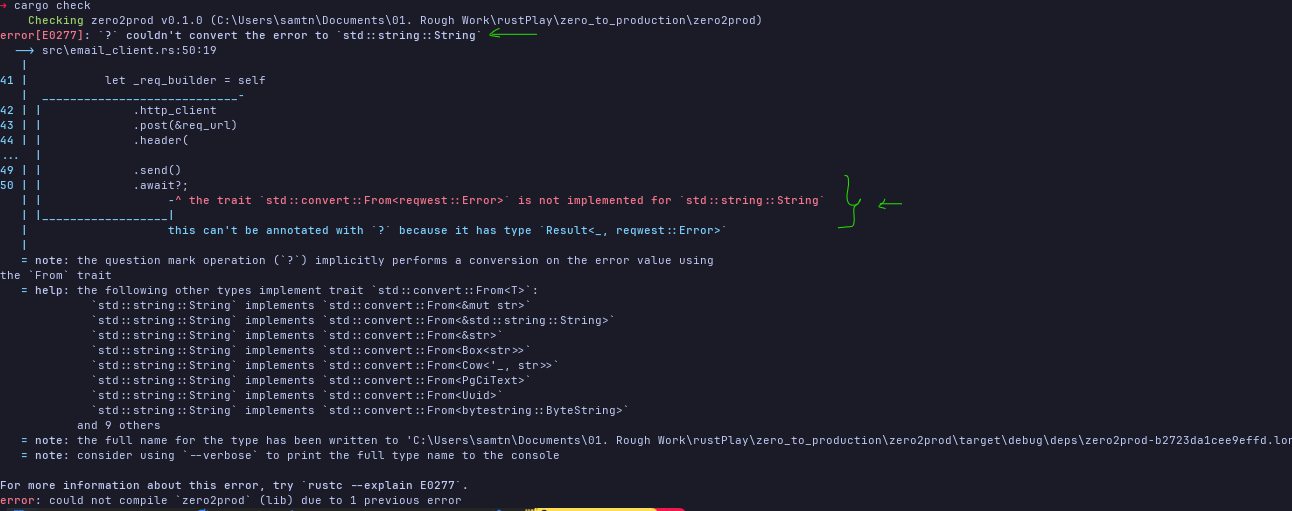

The error variant returned by `send` is of type `reqwest::Error`, while our `send_email` uses`String` as the error type. The compiler has looked for a conversion
(an implementation of the `From` trait), but it could not find any - therefore it errors out.

Because `String` as an error variant was mostly a placeholder - we change the `send_email`'s signature to return `Result<(), reqwest::Error>`.


```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    // [...]

    pub async fn send_email(
        // [...]
    ) -> Result <(), reqwest::Error>
    {
        // [...]
    }
}
```

The error should be gone now & the tests should pass too! Congrats

### 7.2.5. Tightening Our Happy Path Test

#### 7.2.5.0. Overview

Looking at our "happy path" test, we eased ourselves into the world of `wiremock` by starting with something very basic <span>&mdash;</span>.
we are just asserting that the mock server gets called once.

```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {

    use fake::{
        Fake, Faker, ResponseTemplate,
        faker::{
            internet::en::SafeEmail,
            lorem::en::{Sentence, Paragraph},
        }
        matchers::any,
    };
    use secrecy::SecretString;
    use wiremock::{MockServer, Mock};

    use crate::{
        domain::SubscriberEmail,
        email_client::EmailClient,
    };

    #[tokio::test]
    async fn send_email_fires_request_to_base_url() {
        
        // Arrange
        let mock_server = MockServer::start().await;
        let sender_email = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
        let authorization_token = SecretString::from(Faker.fake::<String>())
        let email_client = EmailClient::new(
            mock_server.uri(),
            sender_email,
            authorization_token,
        );

        Mock::give(any())
            .respond_with(ResponseTemplate::new(200))
            .expect(1) // < Expecting just 1 request, and any request (GET, POST, etc) "thus happy path" 
            .mount(&mock_server)
            .await;

        let recipient_email = SubscriberEmail::parse(SafeEmail().fake()).unwrap();
        let subject_line = Sentence(1..3).fake();
        let content = Paragraph(1..10).fake();
        
        // Act
        let _ = email_client.send_email(
            recipient_email,
            &subject_line,
            &content,
            &content
        ).await;

        // Assert
        // Mock expectations are checked on drop
    }
    
}
```

Let's beef it up to check that the outgoing request looks indeed like we expect it to.

#### 7.2.5.0.1. Headers, Path And Method

`any` is not the only matcher offered by `wiremock` out of the box: There are a handful available in `wiremock`'s `matcher` module.

We can use `header_exists` to verify that the `X-Postmark-Server-Token` is set on the request to the server. We can also chain multiple matches together using
the `and` method.<br>
Let's add `header` to check that the `Content-Type` is set to the correct value, `path` to assert on the endpoint being called and `method` to verify the HTTP
verb.

```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {
    // [...]
    use wiremock::matchers::{header, header_exists, path, method};

    #[tokio::test]
    async fn send_email_fires_request_to_base_url() {
        // [...]

        Mock::given(header_exists("X-Postmark-Server-Token"))
            .and(header("Content-Type", "application/json"))
            .and(path("/email"))
            .and(method("POST"))
            .respond_with(ResponseTemplate::new(200))
            .expect(1)
            .mount(&mock_server)
            .await;

        // [...]
    }
}
```

Tests should still pass

#### 7.2.5.0.2. Body

What about the request body.

We could probably use `body_json` match _exactly_ the request body.<br>
We probably do not need to go as far as that <span>&mdash;</span> it would probably be enough to check that the body is valid JSON and it contains
the set of fields names shown in Postmark's example.

There is not out-of-box matcher that suits our needs <span>&mdash;</span> we need to implement our own.
> We could use `body_json_schema`, but it only validates the schema is enforce but not valid JSON for the values.

`wiremock` exposes a `Match` trait - everything that implements it can be used as a matcher in `given` and `and`.

Let's stub it out:

```Rust
//! src/email.rs
// [...]

#[cfg(test)]
mod tests {
    // [...]
    wiremock::{
        Mock,
        MockServer,
        Match, // Trait we use to stub out custom Matcher
        Request,
        ResponseTemplate 
    }

    struct SendEmailBodyMatcher;

    impl Match for SendBodyMatcher {
        fn matches(&self, request: &Request) -> bool {
            // differs from todo!() macro slightly in that todo! is temporary
            // todo!() -> "not YET implemented" i.e temporary
            // unimplemented!() -> "not implemented" i.e more long-term
            unimplemented!() // Just to expose us reader this macro
        }
    }

    
}
```

We get the incoming request as input, `request` (note its of type `wiremock::Request`), and we need to return a boolean value as output
- `true`, if the mock matched,
- `false` otherwise

We need to deserialize the request body as JSON, <span>&mdash;</span> let's add `serde-json` to the list of our development dependencies with
`cargo add serde_json`.<br>
We can now write `matches` implementation

```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {
    // [...]

    struct SendEmailBodyMatcher;

    impl Match for SendEmailBodyMatcher {
        fn matcher(&self, request: &Request) -> bool {
            // Try to parse the body as a JSON value
            let result: Result<serde_json::Value, _> = serde_json::from_slice(&request.body);
            if let Ok(body) = result {
                // Check that all the mandatory fields are populated
                // without inspecting the field values
                body.get("From").is_some()
                    &body.get("To").is_some()
                    &body.get("Suject").is_some()
                    &body.get("HtmlBody").is_some()
                    &body.get("TextBody").is_some()
            } else {
                // If parsing failed, do not match the request
                false
            }
        }
    }

    #[test]
    fn test_send_email_fires_request_to_base_url() {
        // [...]
        Mock.given(header_exists("X-Postmark-Server-Token"))
            .and(header("Content-Type", "application/json"))
            .and(path("/eamil"))
            .and(method("POST"))
            // Using our custom matcher!
            .and(SendEmailBodyMatcher)
            .respond_with(ResponseTemplate::new(200))
            .expect(1)
            .mount(&mock_server)
            .await;
            
    }
}
```

It compiles!<br>
But out tests are failing now...

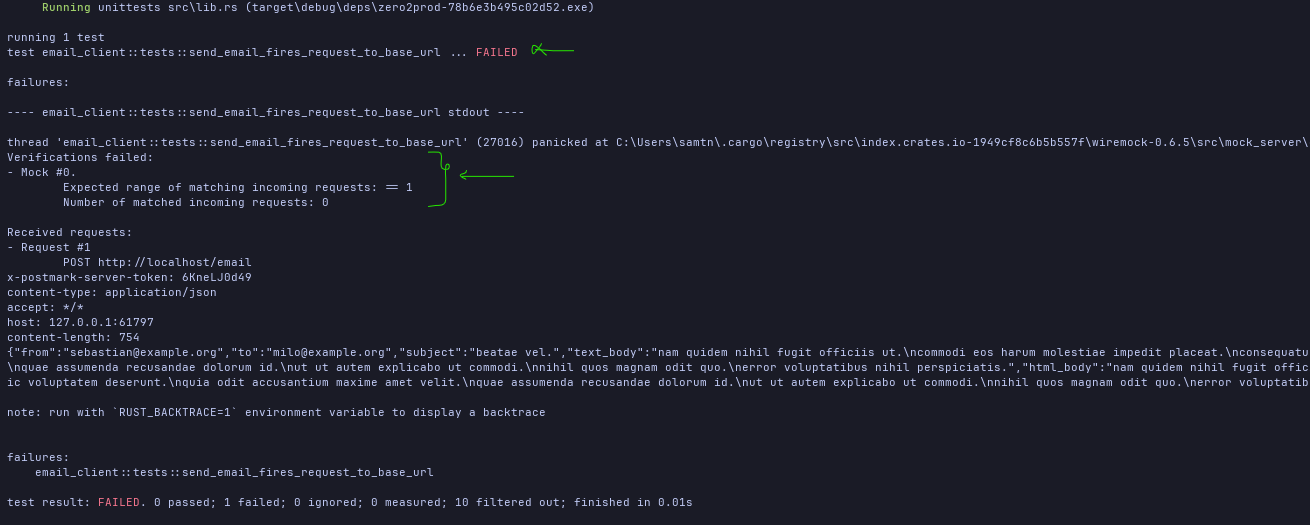

Why is that?<br>
Let's add a `dbg` statement to our matcher to inspect the incoming request:


```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {
    // [...]

    struct SendEmailBodyMatcher;

    impl Match for SendEmailBodyMatcher {
        fn matches(&self, request: &Request) -> bool {
            // [...]
            if let Ok(body) = result {
                dbg!(&body)
                // [...]
            } else {
                false
            }
        }
    }

    #[test]
    fn test_send_email_fires_request_to_base_url() {
        // [...]
        Mock.given(header_exists("X-Postmark-Server-Token"))
            .and(header("Content-Type", "application/json"))
            .and(path("/eamil"))
            .and(method("POST"))
            // Using our custom matcher!
            .and(SendEmailBodyMatcher)
            .respond_with(ResponseTemplate::new(200))
            .expect(1)
            .mount(&mock_server)
            .await;
            
    }
}
```

Running the test again with `cargo test send_email`, we'll get something like this

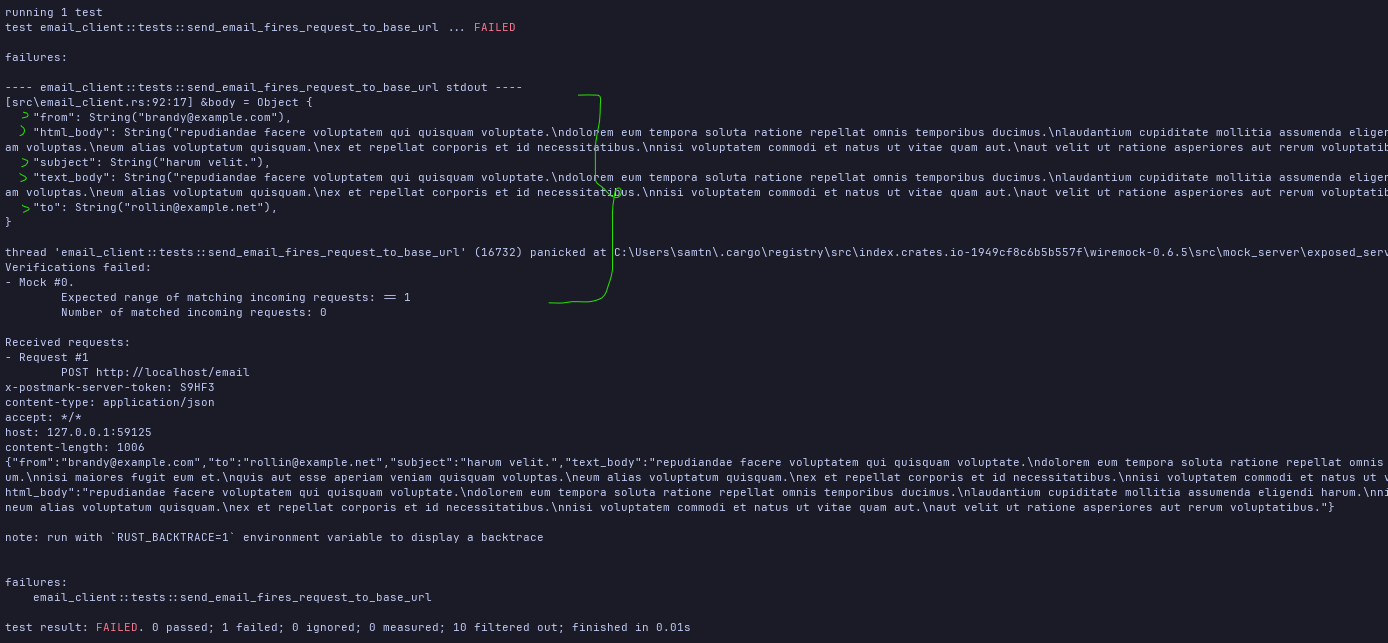

It seems we forgot about the casing requirement <span>&mdash;</span> field names must be pascal cased!
We can fix it easily by adding an annotation on `SendEmailRequestBody`

```Rust
//! src/email_client.rs
// [...]

#[derive(serder::Serialize)]
#[serde(rename_all = "PascalCase")]
struct SendEmailRequestBody {
    from: String,
    to: String,
    subject: String,
    html_body: String,
    text_body: String,
}
```

The test should pass now.<br>
Before we move on, let's rename the test to `send_email_sends_expected_request` <span>&mdash;</span> it captures better the test's purpose at this point

#### 7.2.5.1. Refactoring: Avoid Unnecessary Memory Allocations

We focused on getting `send_email` to work <span>&mdash;</span> now we can look at it again to see if there's any room for improvement.

Let's zoom on the request body:
```Rust
//! src/email_client.rs
// [...]


impl EmailClient {
    // [...]
    pub async fn send_email(
        // [...]
    ) {
        // [...]
        let req_body = SendEmailRequest {
            from: self.sender_email.as_ref().to_owned(),
            to: recipient_email.as_ref().to_owned(),
            subject: subject.to_owned(),
            html_body: html_content.to_owned(),
            txt_body: txt_body.to_owned(),
        };
        // [...]
    }
}


#[derive(serder::Serialize)]
#[serde(rename_all = "PascalCase")]
struct SendEmailRequestBody {
    from: String,
    to: String,
    subject: String,
    html_body: String,
    text_body: String,
}
```

For each field we are allocating a bunch of new memory to store a cloned `String` <span>&mdash;</span> it is wasteful. It would be more efficient to
reference the existing data without performing any additional allocation.<br>
We can pull it off by restructuring `SendEmailRequestBody`: 
> instead of `String` we have to use a string slice (`&str`) as type for all fields.

A string slice is just a pointer to a memory buffer owned by somebody else. To store a reference in a struct we need to add a lifetime parameter: It
keeps track of how long those references are valid for <span>&mdash;</ipan> it's the compiler's job to make sure that references do not stay around
longer than the memory buffer they point to!

```Rust
//! src/email_client.rs
// [...]


impl EmailClient {
    // [...]
    pub async fn send_email(
        // [...]
    ) {
        // [...]
        // No more `.to_owned`
        let req_body = SendEmailRequest {
            from: self.sender_email.as_ref(),
            to: recipient_email.as_ref(),
            subject: subject,
            html_body: html_content,
            txt_body: txt_body,
        };
        // [...]
    }
}


#[derive(serder::Serialize)]
#[serde(rename_all = "PascalCase")]
// Lifetime parameters always start with an apostrophe, `'`
struct SendEmailRequestBody<'a> {
    from: &'a str,
    to: &'a str,
    subject: &'a str,
    html_body: &'a str,
    text_body: &'a str,
}
```

That's it, quick and painless <span>&mdash;</span> `serde` does all the heavy lifting for us and we are left with more performant code!

### 7.2.6. Dealing With Failures

#### 7.2.6.0. Overview

We have a good grip on the happy path <span>&mdash;</span> what happends instead if things don't go as expected?

We'll look at 2 scenarios:
- non-success status codes (e.g. `4xx`, `5xx`, etc);
- slow responses

#### 7.2.6.1. Error Status Codes

Our current happy path test is only making assertions on the side-effect performed by `send_email` <span>&mdash;</span> we are not actually inspecting the
value it returns!<br>
Let's make sre that it is an `Ok(())` if the server returns `200 OK`.

We write a new test `send_email_succeeds_the_server_returns_200()`

```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {
    
    // [...]
    use wiremock::matchers::any;
    use clains::{assert_ok, assert_err};

    #[tokio::test]
    async fn send_email_succeeds_if_server_returns_200() {
        // Arrange
        let mock_server = MockServer::start().await;
        let sender_email = SubscriberEmail::parse(SafeEmail().fake());
        let email_client = EmailClient::new(
            mock_server.uri(),
            sender_email,
            SecretString::from(Faker.fake::<String>()),
        );

        // We don't copy in all the matchers we have in the other test.
        // The purpose of this test is not to assert on the request we
        // are sending out. Its to assert the response we get from the server
        // 
        // We add the bare minimum needed to trigger the path we want to
        // test in `send_email`
        Mock::given(any())
            .respond_with(ResponseTemplate::new(200))
            .expect(1)
            .mount(&mock_server)
            .await;

        let recipient_email = SubscriberEmail::parse(SafeEmail().fake());
        let subject_line = Sentence(1..3).fake();
        let content = Paragraph(1..10).fake();

        // Act
        let outcome = email_client.send_email(
            recipient_email,
            &subject_line,
            &contents,
            &contents,
        )
        .await;

        // Assert
        assert_ok!(outcome);
    }
}
```

No surprises, the test passes.<br>
Let's look at the opposite case now <span>&mdash;</span> we expect an `Err` variant if the server returns a `500 Internal Server Error`

```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {
    
    // [...]
    use clains::{assert_ok, assert_err};

    // [...]
    
    #[tokio::test]
    async fn send_email_fails_if_server_returns_500() {
        // Arrange
        let mock_server = MockServer::start().await;
        let sender_email = SubscriberEmail::parse(SafeEmail().fake());
        let email_client = EmailClient::new(
            mock_server.uri(),
            sender_email,
            SecretString::from(Faker.fake::<String>()),
        );

        Mock::given(any())
            // Not a 200 anymore
            .respond_with(ResponseTemplate::new(500))
            .expect(1)
            .mount(&mock_server)
            .await;

        let recipient_email = SubscriberEmail::parse(SafeEmail().fake());
        let subject_line = Sentence(1..3).fake();
        let content = Paragraph(1..10).fake();

        // Act
        let outcome = email_client.send_email(
            recipient_email,
            &subject_line,
            &contents,
            &contents,
        )
        .await;

        // Assert
        assert_err!(outcome);
    }
}
```

We got some work to do here instead:

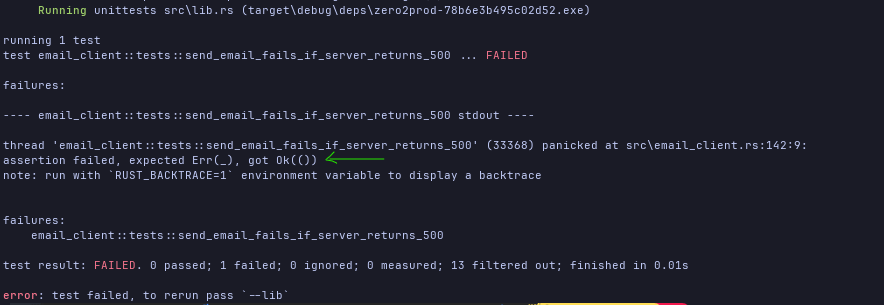

Let's look at `send_email` again:

```Rust
//! src/email_client.rs
// [...]
impl EmailClient {
    //[...]
    pub async fn send_email(
        //[...]
    ) -> Result<(), reqwest::Error> {
        //[...]
        self.http_client
            .post(&url)
            .header(
                "X-Postmark-Server-Token",
                self.authorization_token.expose_secret()
            )
            .json(&request_body)
            .send()
            .await?;
        Ok(())
    }
}
//[...]
```

The only step that might return an error is `send` <span>&mdash;</span> let's check `reqwest`'s docs!

<div style="background: #FFA01F; color: white; padding: 15px; border-radius: 15px;">

This method fails if there was an error while sending request, redirect loop was detected or redirect limit was exhausted
    
</div>

Basically, `send` returns `Ok` as long as it gets a valid response from the the server <span>&mdash;</span> not matter the status code!<br>
To get the behavior we want we need to look at the methods available on `reqwest::Response` <span>&mdash;</span> in particular, `error_for_status`:


<div style="background: #FFA01F; color: white; padding: 15px; border-radius: 15px;">

Turn a response into an error if the server returned an error.
    
</div>

It seems to suit our needs, let's try it out.

```Rust
//! src/email_client.rs
// [...]
impl EmailClient {
    //[...]
    pub async fn send_email(
        //[...]
    ) -> Result<(), reqwest::Error> {
        //[...]
        self.http_client
            .post(&url)
            .header(
                "X-Postmark-Server-Token",
                self.authorization_token.expose_secret()
            )
            .json(&request_body)
            .send()
            .await?
            .error_for_status()?;
        Ok(())
    }
}
//[...]
```

Awesome, the test passes!

#### 7.2.6.2. Timeouts

What happens if the server returns a `200 OK`, but it takes _ages_ to send it back?

We can instruct our mock server to wait a configurable amount of time before sending a response back. Let's experiment a little with a new unittest 
<span>&mdash;</span> what if the server takes **3 minutes** to respond?

```Rust
//! src/email_client.rs
// [...]

#[cfg(test)]
mod tests {
    
    // [...]
    
    #[tokio::test]
    async fn send_email_times_out_if_the_server_takes_too_long() {
        // Arrange
        let mock_server = MockServer::start().await;
        let sender_email = SubscriberEmail::parse(SafeEmail().fake());
        let email_client = EmailClient::new(
            mock_server.uri(),
            sender_email,
            SecretString::from(Faker.fake::<String>()),
        );

        let response = ResponseTemplate::new(200)
            .set_delay(std::time::Duration::from_secs(180)); // 3 minutes delay.
        Mock::given(any())
            .respond_with(response)
            .expect(1)
            .mount(&mock_server)
            .await;

        let recipient_email = SubscriberEmail::parse(SafeEmail().fake());
        let subject_line = Sentence(1..3).fake();
        let content = Paragraph(1..10).fake();

        // Act
        let outcome = email_client.send_email(
            recipient_email,
            &subject_line,
            &contents,
            &contents,
        )
        .await;

        // Assert
        assert_err!(outcome);
    }
}
```

After a while, we should see something like this:

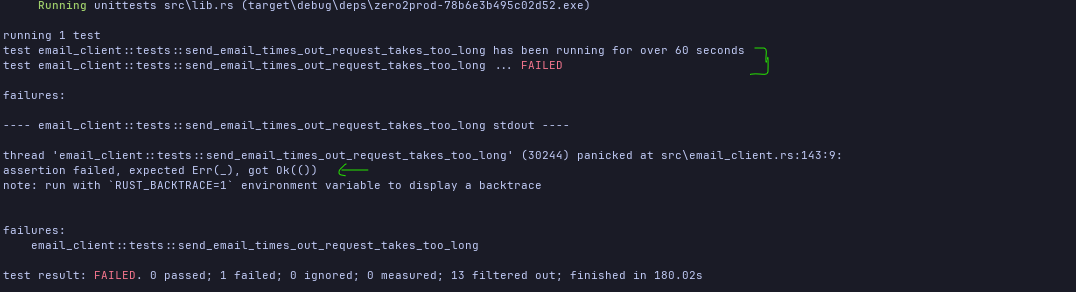

This is far from ideal: if the server starts misbehaving we might start to accumulate several "hanging" requests.<br>
We are not hanging up on the server, so the connection is busy: every time we need to send an email we will have to open a new connection. If the 
server does not recover fast enough, and we do not close any of the open connections, we might end up with socket exhaustion/performance degradation.

> As a rule of thumb: every time we are performing an IO operation, _always_ set a timeout!<br>
> If the server takes longer than the timeout to respond, we should fail and return an error.

Choosing the right timeout value is often more an art than a science, especially if retries are involved: set it too low and we might overwhelm the
server with retried request; set it too high and we risk again to see degradation on the client side.<br>
Nonetheless, better to have a conservative time out than to have none.

<div style="background-color: #BE8FE0; color: white; padding: 15px; border-radius: 15px;">

Is setting an ideal timemout for a server something that _**Machine Learning**_ can be applied to such that it is dynamic depending on traffic to resolve
tension between socket exhaustion/performance degradation on server side vs client side?
 
</div>

`reqwest` gives us two options: 
- we can either add a default timeout on the `Client` itself, which applies to all outgoing requests,
- we can specify a per-request timeout.

Let's go for a `Client`-wide timeout: we'll set it in `EmailClient::new`

```Rust
impl EmailClient {
    pub fn new(
        // [...]
    ) -> Self {
        let http_client = reqwest::Client::builder()
            .timeout(std::time::Duration::from_secs(10))
            .build()
            .unwrap();
        Self {
            http_client,
            base_url,
            sender_email,
            authorization_token
        }
    }
}
// [...]
```

If we run the test again, it should pass (after 10 seconds have elapsed).

#### 7.2.6.3. Refactoring Helpers

There's a lot of duplicated code in our four tests for `EmailClient` <span>&mdash;</span> let's extract the common bits in a set of test helpers.

```Rust
//! src/email_client.rs
// [...]


#[cfg(test)]
mod tests {
    // [...]

    /// Generate a random email subject
    fn subject() -> String {
        Sentence(1..3).fake()
    }
    
    /// Generate  random email content
    fn content() -> String {
        Paragraph(1..10).fake()
    }
    
    /// Generate a random subscriber email
    fn email() -> SubscriberEmail {
        SubscriberEmail::parse(SafeEmail().fake).expect("Failed to parse test email")
    }

    /// Get a test instance of `EmailClient`.
    fn email_cient(base_url: String) -> EmailCient {
        EmailClient::new(
            base_url,
            email(),
            SecretString::from(Faker.fake::<String>()),
        )
    }

    // [...]
    
}
```

Let's use the helpers in `send_email_sends_the_expected_result`:

```Rust
//! src/email_client.rs
// [...]


#[cfg(test)]
mod tests {
    // [...]

    #[tokio::test]
    fn send_email_sends_ecpected_request() {
        let mock_server = MockServer::start().await;
        let email_client = email_client(mock_server.uri());

        Mock::given(header_exists("X-Postmark-Server-Token"))
            .and(header("Content-Type", "application/json"))
            .and(post("/email"))
            .and(method("POST"))
            .and(SendEmailRequestBodyMatcher)
            .expect(1)
            .mount(&mock_server)
            .await;

        let _ = email_client.send_email(
            email(),
            &subject(),
            &content(),
            &content(),
        )
        .await;
    }
}
```

Way less visual noise - the intent of the test is front and center.<br>
Now just to refactor the remaining three.

#### 7.2.6.4. Refactoring: Fail Fast

The timeout on our HTTP client is currently hard-coded to $10$ seconds.

```Rust
pub EmailClient {
    pub fn new(
        // [...]
    ) -> Self {
        let http_client = reqwest::Client::builder()
            .timeout(std::time::Duration::from_secs(10));
        // [...]
    }
}
```

This implies that our timeout test takes roughly 10 seconds to fail <span>&mdash;</span> that is a long time, especially if we are running tests after
every little change.

We make our timeout threshold configurable to keep our test suite responsive.


```Rust
//! src/email_client.rs
// [...]

pub EmailClient {
    pub fn new(
        // [...]
        timout: std::time::Duration,
    ) -> Self {
        let http_client = reqwest::Client::builder()
            .timeout(timeout);
        // [...]
    }
}

//! src/config.rs
// [...]

#[derive(serde::Deserialize)]
pub struct EmailClientSettings {
    // [...]
    pub timeout_milliseconds: u64 // New configuration value!
}

impl EmailClientSettings {
    // [...]
    pub fn timeout(&self) -> std::time::Duration {
        std::time::Duration::from_millis(self.timout_milliseconds)
    }
}

//! src/main.rs
// [...]

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    // [...]
    let timemout = config.email_client.timeout();
    let email_client = EmailClient::new(
        config.email_client.base_url,
        sender
        config.email_client.authorization_token,
        timeout, // Pass new argumeint from configuration
    );

    // [...]
}
```
```yaml
#! configuration/base.yaml
# [...]
email_client:
    # [...]
    timeout_milliseconds: 10000
```

The project should compile.<br>
We still need to update the tests though.

```Rust
//! src/email_client.rs
// [...]


#[cfg(test)]
mod tests {
    // [...]

   fn email_cient(base_url: String) -> EmailCient {
        EmailClient::new(
            base_url,
            email(),
            SecretString::from(Faker.fake::<String>()),
            std::time::Duration::from_millis(200) // Much lower than the default 10 seconds
        )
    }
    // [...]
}

//! tests/health_check.rs
// [...]

async fn spawn_app() -> TestApp {
    // [...]
    let timeout = configuration.email_client.timeout();
    let email_client = EmailClient::new(
        configuration.email_client.base_url,
        sender_email,
        configuration.email_client.authorization_token,
        timeout,
    );
    // [...]
}
```

All test should succeed <span>&mdash;</span> and the overall execution time should be down to less than a second for the whole test suite.

### 7.2.7. Axum implementation.

The implementation of the `EmailClient` remains largely the same. Now axum specific areas were touched and implementation was largely agnostic.

## 7.3. Skeleton And Principles For A Maintainable Test Suite

### 7.3.00. Overview

It took us a bit of work, but we now have a pretty decent REST client for Postmark's API.

`EmailClient` is just the first ingredient for our confirmation email flow: we have yet to find a way to generate unique confirmation links, which we will then have
to embed in the body of the outgoing confirmation email.<br>
Both tasks will have to wait a bit longer.

While we've used a test-driven approach to write all new pieces of functionality throughout the book, we haven't invested a lot of time _refactoring_ our test code.
As a result our intergration test `health_check.rs` is a bit of a mess at this point.<br>
Before moving forward, we will restructure our integration test suite to support us as our application grows in complexity and the number of tests increases.

### 7.3.01. Why Do We Write Tests?

Is writing tests a good use of developers' time?

Short answer, _**Yes**_. Here as some key/main reasons why
- _Tests as a risk-mitigation measure_ <br>
  Automated tests reduce the risk associated with changes to an existing codebase <span>&mdash;</span> most regression bugs are caught in the CI pipeline
  and never reach users. The team is therefore empowered to iterate faster and release more often.
- _Tests as documentation_ <br>
  The test suite is often the best starting point when deep-diving in an unknown code base <span>&mdash;</span> it shows us how the code is meant to behave
  and what scenarios are considered relevant enough to have dedicated tests for.
- _Tests for better code hygiene, and software desing._ <br>
  Writing tests especially <span>&mdash;</span> especially upfront, as in TDD <span>&mdash;</span> pressures us towards loosely coupled, single responsibility code.
  If something is hard to test, that's often a signal the design is tangled
- _Tests reduce debugging time over time._ <br>
  Finding a bug at test-time costs far less than finding it in production. The later a bug surfaces, the more expensive it is: production bugs come
  with user impact, on-call pressure, and harder reproduction conditions.

### 7.3.02. Why Don't We Write Tests?

Although there are compelling reasons to invest time and effort in writing a good test suite, reality is somewhat messier.

The development community did not always believe in the value of testing, it is only with the _"Extrem Programming"_ (XP) book that the practice 
entered mainstream debate <span>&mdash;</span> in 1999.

Still, even while TDD was winning the hearts and minds of developers, the battle with management is often still undergoing.

Honest cases against or limitations of TDD include
- _Tests take real time to write and maintain_ <br>
  A comprehensive test suite for a complex feature can take as long to write as the feature itself. When a deadline is pressing, testing is often
  the first to be sacrificed
- _Tests can give false confidence_ <br>
  A passing test suite doesn't mean the software is correct <span>&mdash;</span> it means it behaves as the tests specify. Poorly written tests
  (testing implementation details, not behavior; missing edge cases; mocking everything away) can make a codebase feel safe while hiding real
  problems.
- _Not all code is equally worth testing_ <br>
  Business-critical payment processing logic and cosmetic UI animation are not the same. Treating them identically leads to wasted effort.

### 7.3.03. Test Code Is Still Code

> Test code is still code

It has to be modular, well-structured, sufficiently documented and requires maintenace.<br>
If we do not actively invest in the health of our test suite, it will rot over time.<br>
Coverage goes down and soon enough we will find critical paths in our application code that are never exercised by automated tests.

We need to regularl step back to take a look at our test suite _as a whole_.<br>
Time to look at ours, isn't it?

### 7.3.04. Our Test Suite

All our integration tests live within a single file, `tests/health_check.rs`:

```Rust
//! tests/health_check.rs
// [...]

#[tokio::test]
async fn health_check_works() {
    // [...]
}

#[tokio::test]
async fn subscribe_retuns_a_400_when_fields_are_present_but_invalid() {
    // [...]
}

#[tokio::test]
async fn subscribe_returns_200_for_valid_form_data() {
    // [...]
}

#[tokio::test]
async fn subscribe_returns_400_when_data_is_missin() {
    // [...]
}

// Ensure that the `tracing` stack is only initialized once using `once_cel`
static TRACING: Lazy<()> = Lazy::new(|| {
   // [...] 
});

pub struct TestApp {
    pub address: String,
    pub db_pool: PgPool,
}

async fn spawn_app() -> TestApp {
    // [...]
}

async fn configure_db(config: &DBSettings) -> PgPool {
    // [...]
}
```

### 7.3.05. Test Discovery

There is only one test dealing with our health check endpoint <span>&mdash;</span> `health_check_works`

The other three tests are probing our `POST /subscriptions` endpoint while the rest of our code deals with shared setup steps
- `spawn_app`
- `TestApp`
- `configure_database`,
- `TRACING`

Our main goal in this refactoring is _discoverability_:
- given an applicatoin endpoint, it should be easy to find hte corresponding integration tests within the `test` folder;
- when writing a test, it should be easy to find the relevant test helper functions.

We will focus on the folder structure, but that is definitely not the only tool available when it comes to test discovery.<br>
Test coverage tools can often tell us which test triggered the execution of a certain line of application code. We can rely on techniques such as
code coverage marks to create an obvious link between test and application code.

As always, a multi-pronged approach is likely to give us the best result as the complexity of our test suite increases.

### 7.3.06. One Test File, One Crate

Before we start moving things around, let's nail down a few facts about integration testing in Rust.<br>
The `tests` folder is somewhat special <span>&mdash;</span> `cargo` knows to look into it searching for intergation tests.

Each file within the `tests` folder gets compiled as its own crate.<br>
We can check this out by running `cargo build --test` and then looking under `target/debug/deps:`

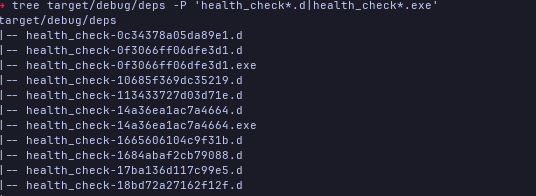

Above is a sample of what we get when we list what is in the directory matching `health_check-*`

Note that when we run the integration tests the output actually shows us the binary that was executed

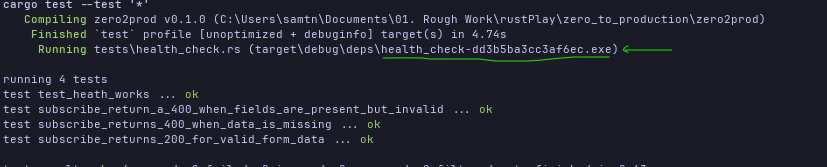


Running it on our own generates the same response

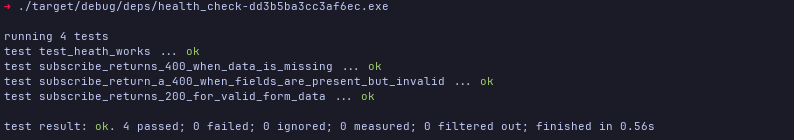

If we have five `*.rs` under `tests`, we'd find five executables in `target/debug/deps`

### 7.3.07. Sharing Test Helpers

If each integration test file is its own executable, how do we share test helper functions?

The first option is to define a stand-alone module e.g. `tests/helpers/mod.rs`.<br>
We can add common functions in `mod.rs` (or define other sub-modules in there) and then refer to helpers in our test file (e.g. 
`tests/health_check.rs`) with:

```Rust
//! tests/health_check.rs
// [...]
mod helpers;

// [...]
```

`helpers` is bundled in the `health_check` test executable as a sub-module and we get access to the functions it exposes in our test cases.<br>
This approach works fairly well to start out, but it leads to annoying `function is never used` warnings down the line.<br>
The issue is that `helpers` is bundled as a sub-module, it is not invoked as a third-party crate: `cargo` compiles each test executable in 
isolation and warns us if, for a specific test file, one or more public functions in `helpers` has never been invoked. This is bound to happen as
our test suite grows <span>&mdash;</span> not all test files will use _all_ our helper methods.

The second option takes full advantage of the fact that each file under `tests` is its own executable <span>&mdash;</span> we can create sub-modules _scoped to a single_executable!_

Let's create an api folder under `tests`, with a single `main.rs` file inside.

```
tests/
|-- api
|   `-- main.rs
`-- health_check.rs
```

First, we get clarity: we are structuring `api` in the very same way we would structure a binary crate. Less magic <span>&mdash;</span> it builds 
on the same knowledge of the module system we build while working on application code. If we run `cargo build --test` we should be able to spot;
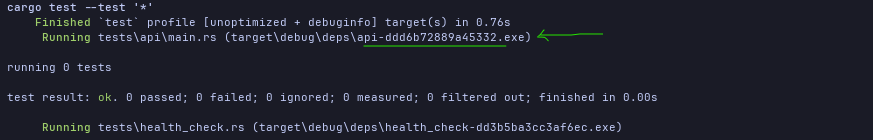

in the output <span>&mdash;</span> cargo compiled `api` as a test executable, looking for test cases<br>
There is no need to define a `main` function in `main.rs` <span>&mdash;</span> the Rust test framework adds one for us behind the scenes.

We can now add sub-modules in `main.rs`

```Rust
//! test/api/main.rs

mod helpers;
mod health_check;
mod subscriptions;
```

We add three empty files
- `tests/api/helpers`
- `tests/api/health_check`
- `tests/api/subscriptions`

Time to delete `tests/health_check.rs` and re-distribute its content:

```Rust
//! tests/api/helpers.rs
use once_cell::sync::Lazy;
use sqlx::{Connection, Executor, PgConnection, PgPool};
use std::net::TcpListener;
use uuid::Uuid;
use zero2prod::{
    config::{get_configuration, DBSettings},
    email_client::EmailClient,
    start_up::run
    telemetry::{get_subscriber, init_subscriber},
};

// Ensure that the `tracing` stack is only initialized once using `once_cell`
static TRACING: Lazy<()> = Lazy::new(|| {
    // [...]
});

pub struct TestApp {
    // [...]
}

pub async fn spawn_app() -> TestApp {
    // [...]
}

async fn config_db(cfg: &DBSettings) -> PgPool {
    // [...]
}

//! tests/api/health_check.rs
use crate::helpers::spawn_app;

#[tokio::test]
async fn health_check_works() {
    // [...]
}

//! tests/api/subscriptions.rs
use crate::helpers::spawn_app;

#[tokio::test]
async fn subcribe_returns_200_if_valid_form_data() {
    // [...]
}

#[tokio::test]
async fn subcribe_returns_400_when_data_is_missing()
    // [...]
}


#[tokio::test]
async fn subcribe_returns_400_when_fields_are_present_but_invalid() {
    // [...]
}
```

`cargo test` should succeed, with no warnings.<br>
Congrats, we have broken down our test suite into smaller and more manageable modules!

There are a few positive side-effects to the new structure: <span>&mdash;</span> it is recursive.<br>
If `tests/api/subsciptions.rs` grows to unwiedly, we can turn it into a moudle, with `tests/api/subscriptions/helpers.rs` holding 
subscription-specific test helpers and one or more test files focused on a specific flow or concern; <span>&mdash;</span> the implementation
details of our helper functions are encapsulated.

It turns out that our tests only need to know about `spawn_app` and `TestApp` <span>&mdash;</span> no need to expose `configure_database`
or `TRACING`, we can keep that complexity hiddent away in the `helpers` module; <span>&mdash;</span> we have a single binary.

If we have a large test suite with a flat structure, we'll soon be building tens of executables every time we run `cargo test`. While each
executable is compiled in parallel, the linking phase is instead entirely sequential! Bundling all our test cases in a single executable 
reduces the time spent compiling our test suite in C.I.

If running on Linux, we might see errors like
```
thread 'actix-rt:worker' panicked at
'Can not create Runtime: Os { code: 24, kind: Other, message: "Too many open files" }',
```

when we run `cargo test` after refactoring.<br>
This is due to a limit enforced by the operating system on the maximum number of open file descriptors (including sockets) for each process <span>&mdash;</span>
give that we are now running all tests as part of a single binary, we might exceed it. The limit is usualy set to $1024$, be we can raise it with `ulimit -n X`
(e.g. `unlimit -n 10000`) to resolve the issue.

### 7.3.08. Sharing Startup Logic
<a id="sharing_startup_logic"></a>

#### 7.3.08.0. Overview

Now that we've reworked the layout of our test suite it's time to zoom in on the test logic itself.<br>
We'll start with `spawn_app`

```Rust
//! tests/api/helpers.rs
// [...]

pub struct TestApp {
    pub address: String,
    pub db_pool: PgPool,
}

pub async fn spawn_app() -> TestApp {
    Lazy::force(&TRACING);

    let listener = TcpListener::bind("127.0.0.1:0").expect("Failed to bind to random port");
    let port = listener.local_addr().unwrap().port();
    let address = format!("http://127.0.0.1:{}", port);

    let mut configuration = get_configuration()
        .expect("Failed to read configuration");
    configuration.db.db_name = format!("newsletter_test_db_actix_{}", Uuid::now_v7());
    let connection_pool = config_db(&configuration.db).await;

    let sender_email = configuration.email_client.sender().expect("Invalid sender email address");
    let timeout = configuration.email_client.timeout();
    let email_client = EmailClient::new(
        configuration.email_client.base_url,
        sender_email,
        configuration.email_client.authorization_token,
        timeout,
    );
    let server = run(listener, connnection_pool.clone(), email_client).expect("Failed to bind address");
    let _ = tokio::spawn(server);
    TestApp {
        address,db_pool: connection_pool,
    }
}
```

Most of the code we have here is extremely similar to what we find in our `main` entrypoint:

```Rust
//! src/main.rs
use sqlx::postgres::PgPoolOptions;
use std::net::TcpListener;
use zero2prod::{
    config::get_config,
    email_client::EmailClient,
    startup::run,
}

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    let subscriber = telemetry::get_subscriber("info".into(), std::io::stdout);
    telemetry::init_subscriber(subscriber);

    let config = get_configuration()
        .expect("Failed to read configuration");
    let connection_pool = PgPoolOptions::new().connect_lazy_with(config.db.connection_string().expose_secret());

    let sender_email = configuration.email_client.sender().expect("Invalid sender email address");
    let timeout = configuration.email_client.timeout();
    let email_client = EmailClient::new(
        configuration.email_client.base_url,
        sender_email,
        configuration.email_client.authorization_token,
        timeout,
    );
    let address = format!("{}:{}", config.app.host, config.app.port);
    let listener = TcpListener::bind(address).unwrap_or_else(|_| panic!("Failed to bind to port: {}", config.app.port));
    
    run(listener, connnection_pool, email_client)?.await?;
    Ok(())
}
```

Every time we add a dependency or modify the server constructor, we have at least 2 places to modify <span>&mdash;</span> we have recently gone through the 
motions with `EmailClient`. It's mildly annoying.<br>
More importantly though, the startup logic in our application code is never tested.<br>
As the codebase evolves, they might start to diverge subtly, leading to different behaviour in our tests compared to our production environment.

We will first extract the logic our of `main` and then figure out what hooks we need to leverage the same code paths in our test code.

#### 7.3.08.1. Extracting Our Startup Code

From a structural perspective, our startup logic is a function taking `Settings` as input and returning an instance of our application as output.<br>
It follows that our `main` function should look like this:
```Rust
use zero2prod::{
    config::get_config,
    startup::build,
    telemetry,
};

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    let subscriber = telemetry::get_subscriber("info".into(), std::io::stdout);
    telemetry::init_subscriber(subscriber);

    let config = config.get_config().expect("Failed to read configuration");
    let server = build(config).await?;
    server.await?;
    Ok(())
}
```

We first perform some binary-specific logic/setup (i.e. telemetry initialisation), then we build a set of configuration values from the supported sources
(yaml files + environment variables) and use it to spin up an application. Let's define that `build` function then

```Rust
//! src/startup.rs
// [...]
// New imports
use crate::config::Settings;
use sqlx::postgres::PgPoolOptions;

pub async fn build(config: Settings) -> Result<Sever, std::io::Error> {

    let connection_pool = PgPoolOptions::new().connect_laxy_with(config.db.connection_string().expose_secrets());

    let sender_email = config.email_client.sender().expect("Invalide sender email address");
    let timeout = config.email_client.timeout();
    let email_client = EmailClient::new(
        config.email_client.base_url,
        sender_email,
        config.email_client.authorization_token,
        timeout
    )
    
    let address = format!("{}:{}", config.app.host, config.app.host);
    
    let listener = TcpListener::bind(address)?;
    run(listener, connection_pool, email_cilent)
}

// Removed the pub access modifier
async fn run (listener: TcpListner, db_pool: PgPool, email_client: EmailClient) -> Result<Server, std::io::Error> {
    // [...]
}
```

Nothing too surprising <span>&mdash;</span> we have just moved around the code that was previously living in `main`.<br>
Let's make the `build` functionon test-friendly now.

#### 7.3.08.2. Testing Hooks In Our Startup Logic

Let's look at out `spawn_app` function again:
```Rust
//! tests/api/helpers.rs
// [...]

pub async fn spawn_app() -> TestApp {
    // The first time `initialize` is invoked the code in `TRACING` is executed.
    // All other invocations will skip execution.
    Lazy::force(&TRACING);

    let listener = TcpListener::bind("127.0.0.1:0")
        .expect("Failed to bind random port");
    // We retrieve the port assigned to us by the OS
    let port = listener.local_addr().unwrap().port();
    let address = format!("127.0.0.1:{}", port);

    let mut configuration = get_configuration()
        .expect("Failed to read configuration");
    configuration.db.db_name = format!("newsletter_test_db_actix_{}", Uuid::now_v7());
    let connection_pool = config_db(&configuration.db).await;
    let sender_email = configuration.email_client.sender().expect("Invalid sender email address");
    let timeout = configuration.email_client.timeout();
    let email_client = EmailClient::new(
        configuration.email_client.base_url,
        sender,
        configuration.email_client.authorization_token,
        timeout,
    );

    let server = run(listener, connection_pool.clone(), email_client).expect("Failed to bind address");
    let _ = tokio::spawn(server);
    TestApp {
        address,
        db_pool: connection_pool,
    }
}
// [...]
```

At a high level, we have the folling phases:
- Execute test-specific setup (i.e. initialize a `tracing` subscriber);
- Randomize the configuration to ensure tests to do not interfere with each other (i.e. different logical database for each test case);
- Initialize external resources (e.g. create and migrate the database);
- Build the application
- Launch the application as a background task and return a set of resources to interact with it.

We _can't_ just throw `startup::build` in there and call it a day. Here's why;

```Rust
//! tests/api/helpers.rs
// [...]
// New import
use zero2prod::startup::build;

pub async fn spawn_app() -> TestApp {
    // The first time `initialize` is invoked the code in `TRACING` is executed.
    // All other invocations will skip execution.
    Lazy::force(&TRACING);

    // Randomize configuration to ensure test isolation
    let configuration = {
        let mut c = get_config().expect("FAiled to read configuration.");
        // Use a different database for each test case
        c.db.db_name = format!("newsletter_test_db_actix_{}", Uuid::now_v7());
        // Use a random OS port
        c.app.port = 0
        c;
    }

    // Create and migrate the database
    configure_db(&configuration.db).await;

    // Launch the application as a background task
    let server = build(configuration).await.expect("Failed to bind address");
    let _ = tokio::spawn(server);
    TestApp {
        address: todo!(),
        db_pool: todo!(),
    }
}
// [...]
```

The approach falls short at the very end: we have no way to retrieve the random address assigned by the OS to the application and we don't really know how to
build a connection pool to the database, needed to perform assertions on side-effects impacting the persisted state.

Let's deal with the connection pool first: we can extract the initialization logic from `build` into a stand-alone function and invoke it twice
```Rust
//! src/startup.rs
// [...]
use crate::config::DBSettings;

pub async fn build(cfg: Settings) -> Result<Server, std::io::Error> {
    let connection_pool = get_connection_pool(&cfg.db);
    // [...]
}

pub fn get_connection_pool (config: DBSettings) -> PgPool {
    PgPoolOptions::new().connect_lazy_with(config.connection_string().expose_secrets())
}

//! tests/api/helpers.rs
// [...]
use zero2prod::startup::{build, get_connection_pool};
// [...]

pub async fn spawn_app() -> TestApp {
    // Notice the `.clone()`
    let server = build(configuration.clone())
        .await
        .expect("Failed to build application.");
    // [...]
    TestApp {
        address: todo!(),
        db_pool: get_connection_pool(&config.db),
    }
}
```
> We'll have to add a `#[derive(Clone)]` to all structs in `src/configuration.rs` to make the compiler happy, but we are done with the database connection pool.

How do we get the application address now?<br>
`actix_web::dev::Server`, the type returned by `build`, does not allow us to retrieve the application port.<br>
We need to to a bit more legwork in our application code <span>&mdash;</span> we will wrap `actix_web::dev::Server` in a new type that holds on to the information
we want.

```Rust
//! src/startup.rs
// [...]

// A new type to hold the newly built server and its port
pub struct Application {
    port: u16,
    server: Server,
}

impl Application {
    // We have converted the `build` function into a constructor for 
    // `Application`.
    pub async fn build(config: Settings) -> Result<Self, std::io::Error> {
        let connection_pool = get_connection_pool(&config.db);

        let sender_email = config.email_client.sender().expect("Invalid sender email address");
        let timout = config.email_client.timout();
        let email_client = EmailClient::new(
            config.email_client.base_url,
            sender,
            config.email_client.authorization_token,
            timeout,
        );

        let address = format!("{}:{}", config.app.host, config.app.port);
        let listener = TcpListener::bind(address)?;
        let port = listener.local_addr().unwrap().port();
        let server = run(listener, connection_pool, email_cient)?;

        // We "save" the bound port in one of `Applications`'s fields
        Ok(Self { port, server})
    }

    pub fn port(&self) -> u16 {
        self.port
    }

    // A more expressive name that makes it clear that 
    // this function only returns when the application is stopped.
    pub async fn run_until_stopped(self) -> Result<(), std::io::Error> {
        self.server.await
    }
}
```

```Rust
//! tests/api/helpers.rs
// [...]
// New import

use zero2prod::startup::Application;

pub async fn spawn_app() -> TestApp {
    // [...]
    let application = Application::build(configuration.clone())
        .await
        .expect("Failed to build application");
    // Get the port before spawning the application
    let address = format!("http://127.0.0.1:{}", application.port());
    let _ = tokio::spawn(application.run_until_stopped());

    TestApp {
        address,
        db_pool: get_connection_pool(&configuration.db),
    }
}


//! src/main.rs
// [...]
// New import
use zero2prod::startup::Application;

#[tokio::main]
async fn main() -> Result<(), std::io::Error> {
    // [...]
    let application = Application::build(config).await?;
    application.run_until_stopped().await?;
    Ok(())
}
```

It's done <span>&mdash;</span> run `cargo test` to double check!

### 7.3.09. Building An API Client

All of our integration tests are black-box: we launch our applicaton at the beginning of each test and interact with it using a HTTP client (i.e. `reqwest`).<br>
As we write tests, we necessarily end up implementing a client for our own API.

That's great!<br>
It gives us an opportunity to see what it feels like to interact with the API as a user.
We just neeed to be careful not to spread the client logic all over the test suite <span>&mdash;</span> when the API changes, we don't want to go through tens
of tests to remove the trailing "s" from `/subscriptions` from the path of our endpoint for example.

Looking at our subscriptions tests, we have some calling code in each test.

```Rust
//! tests/api/subscriptions.rs
use crate::helper::spawn_app;

#[tokio::test]
async fn subscribe_returns_400_when_fields_are_presents_but_invalid(){
    // Arrange
    let app = spawn_app().await;
    let client = reqwest::Client::new();
    let test_cases = vec![
        ("username=&email=lei_yin_loo%40gmail.com", "empty name"),
        ("username=lei&email=", "empty email"),
        (
            "username=lei&email=definitely-not-an-email",
            "invalid email",
        ),
    ];
    for (body, description) in test_cases {
        // Act
        // DUPLCIATE CALLING CODE
        let response = client
            .post(format!("{}/subscriptions", &app.address))
            .header("Content-Type", "application/x-www-form-urlencoded")
            .body(body)
            .send()
            .await
            .expect("Failed to execute request.");

        // Assert
        assert_eq!(
            400,
            response.status().as_u16(),
            "The API did not return a 400 Bad Request when the payload was {}.",
            description
        )
    }

}

#[tokio::test]
async fn subscribe_returns_200_for_valid_form_data() {
    // Arrange
    let app = spawn_app().await;
    let client = reqwest::Client::new();

    // Act
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";
    // DUPLCIATE CALLING CODE
    let response = client
        .post(format!("{}/subscriptions", &app.address))
        .header("Content-Type", "application/x-www-form-urlencoded")
        .body(body)
        .send()
        .await
        .expect("Failed to execute request.");

    // Assert
    assert_eq!(200, response.status().as_u16());

    let saved = sqlx::query!("SELECT email, username FROM subscriptions",)
        .fetch_one(&app.db_pool)
        .await
        .expect("Failed to fetch saved subscription.");

    assert_eq!(saved.email, "lei_yin_loo@gmail.com");
    assert_eq!(saved.username, "lei yin");
}

#[tokio::test]
async fn subscribe_returns_400_when_data_is_missing() {
    // Arrange
    let app = spawn_app().await;
    let client = reqwest::Client::new();
    let test_cases = vec![
        ("username=lei%20yin", "missing the email"),
        ("email=lei_yin_loo%40gmail.com", "missing the name"),
        ("", "missing both name and email"),
    ];

    for (invalid_body, error_message) in test_cases {
        // Act
        // DUPLCIATE CALLING CODE
        let response = client
            .post(format!("{}/subscriptions", &app.address))
            .header("Content-Type", "application/x-www-form-urlencoded")
            .body(invalid_body)
            .send()
            .await
            .expect("Failed to execute request");

        assert_eq!(
            400,
            response.status().as_u16(),
            // Additional customized error message on test failure
            "The API did not fail with 400 Bad Request when the payload was {}.",
            error_message
        )
    }
}

```

We should pull out the duplicate code and add a helper method to our `TestApp` struct

```Rust
//! tests/api/helpers.rs
// [...]

pub struct TestApp{
    // [...]
}

impl TestApp {
    pub async fn post_subscriptions(&self, body: String) -> reqwest::Response {
        reqwest::Client::new()
            .post(format!("{}/subscriptions", &self.address))
            .header("Content-Type", "application/x-www-form-urlencoded")
            .body(body)
            .send()
            .await
            .expect("Failed to execute request")
    }
}

// [...]


//!tests/api/subscriptions.rs
use crate::helpers::spawn_app;


#[tokio::test]
async fn subscribe_returns_400_when_fields_are_present_but_invalid() {
    // [...]
    for (body, error_message) in test_cases {
        let response = app.post_subscriptions(body.into()).await;
        // [...]
    }
}

#[tokio::test]
async fn subscribe_returns_200_for_valid_form_data() {
    // [...]
    // Act
    let response = app.post_subscriptions(invalid_body.into()).await;
    // [...]
}

#[tokio::test]
async fn subscribe_returns_400_when_data_is_missing() {
    // [...]
    for (invalid_body, error_message) in test_cases {
        let response = app.post_subscriptions(invalid_body.into()).await;
        // [...]
    }
}
```

We could add another method for the health check endpoint, but it's only used once <span>&mdash;</span> there is no need right now.

### 7.3.x. Axum implementation

The biggest difference in the Axum specific implementation comes down to the ["Sharing Startup Logic"](#sharing_startup_logic) section. Because in axum we don't return an instance of a 
`Server` we have to modify our `Application` struct to house a `port`, `router` & `listener` then call `axum::serve` in our `run_until_stopped` method. The implemetation looks as follows

```Rust
//! src/startup.rs
// [...]

// New imports
use crate::{
    config::{DBSettings, Settings},
    email_client::EmailClient,
};

use sqlx::{PgPool, postgres::PgPoolOptions};

pub struct Application {
    port: u16,
    listener: TokioTcpListener,
    router: Router,
}

impl Application {
    pub async fn build(config: Settings) -> Result<Self, std::io::Error> {
        // Setup `listener`
        let address = format!("{}:{}", config.app.host, config.app.port);
        let listener = TokioTcpListener::bind(address)
            .await
            .expect("Failed to bind to port in build");
        let port = listener.local_addr().unwrap().port();

        // Setup `connection_pool`
        let connection_pool = get_connection_pool(&config.db);

        // Setup `email_cliant`
        let base_url = config.email_client.base_url();
        let sender_email = config.email_client.sender()
            .expect("Invalid sender email address");
        let timeout = config.email_client.timeout();
        let email_client = EmailClient::new(
            base_url,
            sender_email,
            config.email_client.authorization_token,
            timeout,
        );
        
        // Build `router`
        let router = build_router(connection_pool, email_client);

        // return
        Ok( Self { port, listener, router })
    }

    pub fn port(&self) -> u16 {
        self.port
    }

    pub async fn run_until_stopped(self) -> Result<(), std::io::Error> {
        println!("👂Listening on {}", &self.listener.local_addr().unwrap());
        axum::serve(self.listener, self.router)
            .with_graceful_shutdown(shutdown_signal())
            .await
    }
}

pub fn get_connection_pool(config: &DBSettings) -> PgPool {
    PgPoolOptions::new().connect_lazy_with(config.connect_options())
}

#[derive(Clone)]
struct AppState {
    pub db_pool: PgPool,
    pub email_client: Arc<EmailClient>,
}

fn build_router (db_pool: PgPool, email_client: EmailClient) -> Router {
    // Setup Tracing
    let tracing_layer = TraceLayer::new_for_http()
        .make_span_with(|request: &http::Request<_>| {
            let request_id = Uuid::now_v7();
            tracing::info_span!(
                "http_request",
                method = %request.method(),
                uri = %request.uri(),
                request_id = request_id
            )
        })
        .on_response(
            |response: &http:Response<_>, latency: Duration, _span: &Span | {
                tracing::info!("response: {} {:?}", response.status(), latency)
            },
        )
        .on_failure(
            |error: &ServerErrorsFailureClass, _latency: Duration, _span: &Span | {
                tracing::error!("error: {}", error)
            },
        );
        
    // Instantiate App State
    let state = AppState { db_pool, email_cient: Arc::new(email_cient) };
    
    // Build router
    let router = Router::new()
        .route("/health_check", get(health_check))
        .route("/subscriptions", post(health_check))
        .route("/", get(greet))
        .route("/{name}", get(greet))
        .layer(tracing_layer)
        .with_state(state)
}

// [...]
```

Our `tests/api/common.rs` which is `test/api/helper.rs` in our actix implementation remains largely the same just instead or running the server, we run the app instance.
```Rust
//! tests/api/common.rs
// [...]
// New import
use startup::Application;

// [...]

async fn spawn_app(){

    LazyLock::force(&TRACING);

    let configuration = {
        let mut config = get_config().expect("Failed to read configuration");
        config.db.db_name = format!("newsletter_axum_test_db_{}", Uuid::now_v7());
        config.app.port = 0;
        config
    };

    configure_db(&config.db).await;

    let app = Application::build(configuration.clonw()).await;

    let address = format!("http://127.0.0.1:{}", app.port());
    tokio::spawn(app.run_until_stopped());

    TestApp {
        address,
        db_pool: get_connection_pool(&configuration.db);
    }
}

// [...]
```

Everything else on refactoring our test suite to become more scalable does not axum specific changes to run. Everything else was a straight forward port code for code.

### 7.3.10. Summary

We started with a single file test suite, we finished with a modular test suite and a robust set of helpers. Just like application code,
test code is never finished: we will have to keep working on it as the project evolves, but we have laid down solid foundations to keep moving
forward without losing momentum.<br>
We are now ready to tackle the remaining pieces of functionality needed to dispatch a confirmation email.

## 7.4. Refocus

Time to go back to the plan we drafted at the beginning of the chapter:

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: solid 1px gray;">

- [x] write a module to send an email
- [ ] adapt the logic of our existing `POST /subscriptions` request handler to match the new requirements;
- [ ] write a `GET /subscriptions/confirm` request handler from scratch.
    
</div>

The first item is done, time to move on to the remaining two on the list.<br>
We had a sketch of how the two handlers should work:

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: solid 1px gray;">

`POST /subscriptions` will:
- add the subscriber details to the database in the `subscriptions` table, with `status` equal to `pending_confirmation`;
- generate a unique `subscription_token`;
- store `subscription_token` in our database against the subscriber `id` in a `subscription_token` table;
- send and email to the new subscriber containing a link structured as <a href=""> https://<api-domain>/subscriptions/confirm?token=<subscription_token></a>;
- return a `200 OK`

Once the click on the link. a browser tab will open and a `GET` request will be fired to our `GET /subscriptions/confirm` endpoint. The request handler will;
- retrieve `subscription_token` from the query parameters;
- retrieve the subscriber `id` associated with `subscription_token` from the `subscription_token` table;
- update the subscriber status from `pending_confirmation` to `active` in the `subscriptions_table`;
- return a `200 OK`

</div>

<div style="background-color: #262933; color: white; padding: 15px;">
    
**Note**: 

_Once the click on the link, a browser tab will open and a `GET` request will be fired to our `GET /subscriptions/confirm` endpoint._ 

In our implementation we will make the request to `subscriptions/confirm` endpoint a `POST` request to make it semantically correct 
because we are mutating our application state changing a subscriber from `pending_confirmation` to `active`

Reems like there's already an issue raised around this on the project repository [here](https://github.com/LukeMathWalker/zero-to-production/issues/187).
</div>

This gives us a fairly precise picture of how the application is going to work once we are done with the implementation.<br>
It doesn't help us much to figure out **how to get there**.

Where should we start from?<br>
Should we immediately tackle the changes to `subscriptions`?<br>
Should we get `/subscriptions/confirm` out of the way?

We need to find an implementation route that can be rolled out with **zero downtime**.

## 7.5. Zero Downtime Deployment

### 7.5.1. Reliability

In Chapter 5 we deployed our application to a public cloud provider.<br>
It is live: we are not sending out newsletter issues yet, but people can subscrive while we figure that part out. 

Once an application is serving production traffic, we need to make sure it is **reliable**.

Reliable means different things in different contexts. If we are selling a data storage solution, for example, it should not lose
(or corrupt) customer's data.

In a commercial setting, the definition of reliability for our application will often be encoded in a Service Level Agreement (SLA).<br>
An SLA is a contractual obligation: we guarantee a certain level of reliability and commit to compensate our customers (usually with
discounts or credits) if our service fails to live up to the expectations.

If we are selling access to an API, for example, we will usually have something related to **availability** <span>&mdash</span> e.g. the
API should successfully respond to at least $99.99\%$ of well-formed incoming requests, often referred to as _"four nines of availability"_.<br>
Phrased differently (assuming a uniform distribution of incoming request over time), we can only afford up to $52$ minutes of downtime over
a whole year. Achieving four nines of availability is tough.

There's no silver bullet to build a highly available solution: it requires work from the application layer all the way down to the infrastructure
layer.<br>
One thing is certain, though: if we want to operate a highly available service, we should master **zero downtime deployments** <span>&mdash</span>
users should be able to use the service before, during and after the rollout of a new version of the application to production.

This is even more important if we're practising continous deployment: we cannot release multiple times a day if every release triggers a small
outage.

### 7.5.2. Deployment Strategies

#### 7.5.2.1. Naive Deployment

Before diving deeper into zero downtime deployment, let's have a look at the "naive" approach.
Version A of our service is running in production and we want to roll out version B:
- We switch off all instances of version A running in the cluster;
- We spin up new instances of our application running version B;
- We start serving traffic using version B.

There is a non-zero amount of time where there is no application running in the cluster able to serve user traffic 
<span>&mdash</span> we are experiencing downtime!

To do better we need to take a closer look at how our infrastructure is set up.

#### 7.5.2.2. Load Balancers

##### 7.5.2.2.0. Overview

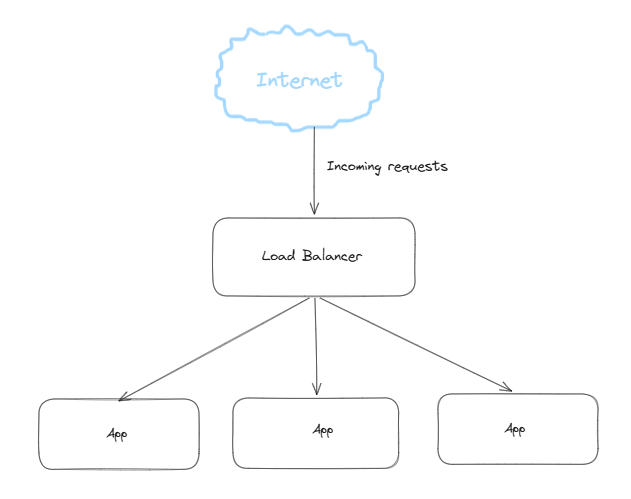

We have multiple copies of our application running behind a **load balancer**.
> We might recall that we set the number of replicas to 1 in chapter 5 to reduced the bill while experimenting. Even if we are running
> single replica there is a load balancer bebween our users and our application. Deployments are still performed using a rolling-update
> stratergy. More on this in a bit.

Each replica of our appliation is registered with the load balancer as a **backend**.<br>
Every time somebody sends a request to our API, they hit our load balancer which is then in charge of choosing one of the available 
backends to fulfill the incoming request.

Load balancers usually support adding (and removing) backends dynamically.<br>
This enables a few interesting patterns

##### 7.5.2.2.1. Horizontal Scaling

We can add more capacity when experiencing a traffic spike by spinning up more replicas of our application (i.e. horizontal
scaling).<br>
It helps to spread the load until the work expected of a single instance becomes manageable.

We will get back to this topic later in the book when discussing metrics and autoscaling

##### 7.5.2.2.2. Health Check

We can ask the load balancer to keep an eye on the **health** of the registered backends.<br>
Oversimplifying, health checks can be:
- Passive - the load balancer looks at the distribution of status codes/latency for each backend to determine
  if they are healthy or not;
- Active - the load balancer is configured to send a health check request to each backeknd on a schedule. If a
  backend fails to respond with a success status code for a long enough time period it is marked as unhealthy and
  removed.

This is a critical capability to achiev **self-healing** in a cloud-native environment: the platform can detect if an
application is not behaving as expected and automatically remove it from the list of available backends to mitigate or
nullify the impact on users.
> This is true as long as the platform is also capable of automatically provisioning a new replica of the application when
> the number of healthy instances falls below a pre-determined threshold.

#### 7.5.2.3. Rolling Update Deployment

We can leverage a load balance to perform zero downtime deployments.

Looking at the image snapshot of a production environment: we have three replicas of version A of an application registered as
backends for our load balancer.

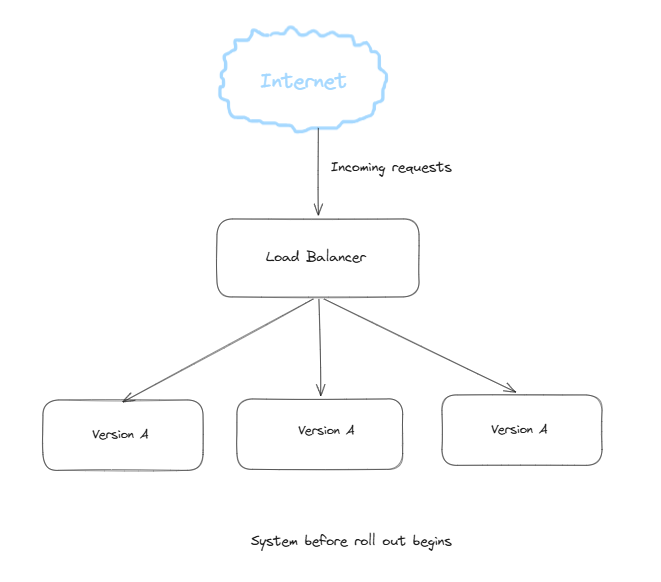

We want to deploy version B.

We start by spinning up one replica of version B of our application.<br>
When the application is ready to serve traffic (i.e. a few health check request have suceeded) we register it as a backend with our
load balancer.

We have four replicas of our application now: 3 running version A, 1 running  version B. **All four** are serving live traffic.

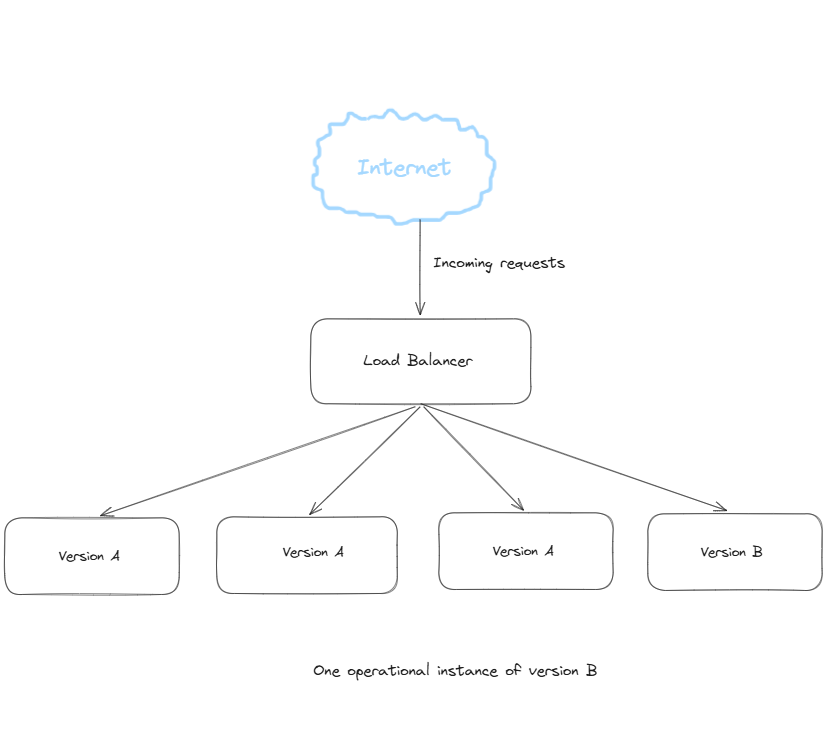

If all is well, we switch off one of the replicas running version A.

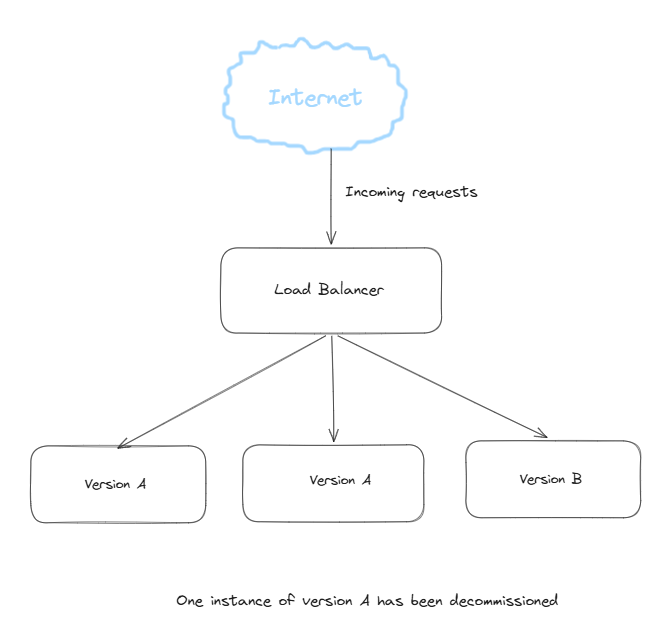

We follow the same process to replace all replicas running version A until all registed backends are running version B.

This deployment strategy is called **rolling update**: we run the old and the new version of the application side by side,
serving live traffic with both.<br>
Throughout the process we always have three or more healthy backends: users should not experience any kind of service
degradation (assuming version B is not buggy).

#### 7.5.2.4. Digital Ocean App Platform

The book's implementation of the application runs on Digital Ocean.<br>
Their documentation boasts of offering zero downtime deployments out of the box, but they do not provide details on how it is achieved.

A few experiments confirmed that they are indeed relying on a rolling update deployment strategy.

A rolling update is not the only possible strategy for zero downtime deployment <span>&mdash;</span> blue-green and canary deployments
are equeally popular variations over the same underlying principles.<br>
We choose the most appropriate solution for our application based on the capabilities offered by our platform and our requirements.

#### 7.5.2.5. Fly.io Platform

[Fly.io](Fly.io) also offers zero downtime deployment out of the box with rolling update deployment strategy as the default. The deployment
stragey is configurable so one can set the strategy most appropriate for their requirements.

The two canonical resources raging this are
- [fly.io/docs/blueprints/seamless-deployments/](fly.io/docs/blueprints/seamless-deployments/) <span>&mdash;</span> the practical guide
covering strategies, health checks, and release commands.
- [fly.io/zero-downtime-deploys](fly.io/zero-downtime-deploys) <span>&mdash;</spann> the higher-level overview page

## 7.6. Database Migrations

### 7.6.1. State Is Kept Outside The Application

Load balancing relies on a strong assumption: no matter which backend is used to server an incoming request, the outcome will be
the same.

This is something we discussed already in Chapter 3: to ensure high availability in a fault-prone environment, cloud-native applications
are **stateless** <span>&mdash;</span> they delegate all persistence concerns to external systems (i.e. databases).

That's why load balancing works: all backends are talking to the same database to query and manipulate the same **state**.

### 7.6.2. Deployments And Migrations

During a rolling update deployment, the old and the new versions of the application are both serving live traffic, side by side.<br>
From a different perspective: the old and the new version of the application are using the **same database** at the **same time**.

To avoid downtime, we need a database schema that is understood by both versions.<br>
This is not an issue for most of our deployments, but it is a serious constraint when we need to evolve the schema.

Let's circle back to the job set out to do, confirmation emails.<br>
To move forward with the implementaiton strategy we identified, we need to evolve our database schema as follows
- add a new table, `subscription_token`.
- add a new mandatory column, `status`, to the existing `subscriptions` table.

Let's go over the possible scenarios to convince ourselves that we cannot possibly deploy confirmation emails all at once without
incurring downtime.

_We could first migrate the database and then deploy the new version._<br>
This implies that the current version is running against the migrated database for some time: our current implementation of 
`POST /subscriptions` does not know about `status` and it tries to insert new rows into `subscriptions` without populating it.
Given that `status` is constrained to be `NOT NULL` (i.e. it's mandatory), all inserts would fail <span>&mdash;</span> we would
not be able to accept new subscribers until the new version of the application is deployed.<br>
Not good.

_We could first deploy the new version and then migrate the database._<br>
We get the opposite scenario: the new version of the application is running against the old database schema.
When `POST /subscriptions` is called, it tries to insert a row into `subscriptions` with a `status` field that doesn't exist
<span>&mdash;</span> all inserts fail and we cannot accept new subscribers until the database is migrated.<br>
Once again, not good.

### 7.6.3. Multi-Step Migrations

A big bang release won't cut it <span>&mdash;</span> we need to get there in multiple, smaller steps.<br>
The pattern is somewhat similar to what we see in test-driven development: we don't change code and tests at the same time
<span>&mdash;</span> one of the two needs to stay still while the other changes.

The same applies to database migrations and deployments: if we want to evolve the database schema we cannot change the application
behaviour at the same time.<br>
Think of it as a database refactoring: we are laying down the foundations in order to build the behavior we need later on.

### 7.6.4. A New Mandatory Column

Let's start by looking at the `status` column.

#### 7.6.4.1. Step1: Add As Optional

We start by keeping the application code stable. A.K.A. _Leave as is for now._

On the database side, we generate a new migration script:

```bash
> sqlx migrate add add_status_to_subscriptions.sql
Creating migrations/20260502121348_add_status_to_subscriptions.sql
```

We can now edit the migration script to add `status` as an **optional** column to subsriptions:
```SQL
ALTER TABLE subscriptions ADD COLUMN status TEXT NULL;
```

We run the migration against our local database (`SKIP_DOCKER=true ./scripts/init_db.sh`): we can now run our test suite to make
sure that the code works as is, even against the new database schema.

It should pass: we should go ahead and migrate the production database.
> _I think for fly.io we are can execute the migration commands on the server via ssh-ing to the db instance._

#### 7.6.4.2. Step 2: Start Using The New Column 

`status` now exists: we can start using it!<br>
To be precise, we can start writing to it: every time a new subscriber is inserted, we will set status to `confirmed`.

We just need to change our insertion query from
```Rust
//! src/routes/subscriptions
// [...]

pub async fn insert_subscriber([...]) -> Result<(), sqlx::Error> {
    sqlx::query!(
        r#"
            INSERT INTO subscriptions (id, email, username, subscribed_at)
            VALUES ($1, $2, $3, $4)
        "#,
        // [...]
    )
    // [...]
}
```
to 
```Rust
//! src/routes/subscriptions
// [...]

pub async fn insert_subscriber([...]) -> Result<(), sqlx::Error> {
    sqlx::query!(
        r#"
            INSERT INTO subscriptions (id, email, username, subscribed_at, status)
            VALUES ($1, $2, $3, $4, 'confirmed')
        "#,
        // [...]
    )
    // [...]
}
```

Tests should pass - deploy the new version of the application to production.

#### 3.6.4.3. Step 3: Backfill And Mark As `NOT NULL` 

The latest version of the application ensures that `status` is populated for all new subscribers.<br>
To mark `status` as `NOT NULL` we just need to back fill the value for historical records? we'll then be free to alter the column.

Let's generate a new migration script:


```bash
> sqlx migrate add backfill_status_column_and_make_non_null
Creating migrations/20260502131443_backfill_status_column_and_make_non_null.sql
```

The SQL migration might look like this
```SQL
-- We wrap the whole migratinoo in a transaction to make sure
-- it succeeds or fails atomically. We will discuss SQL transactions
-- in more detail towards the end of this chapter!
-- `sqlx` does not do it automatically for us.
BEGIN;
    -- Backfill `status` for historical entries
    UPDATE subscriptions
        SET status = 'comfirmed'
        WHERE status IS NULL;
    -- Make `status` mandatory
    ALTER TABLE subscriptions ALTER COLUMN status SET NOT NULL;
COMMIT;
```

We can migrate our local database, run our test suite and then deploy our production database.<br>
We made it, we added `status` as a new mandatory column!

### 7.6.5. A New Table

What about `subscriptions_tokens`? Do we need three steps there as well?

No, it is much simpler: we add the new table in a migration while the application keeps ignoring it.<br>
We can then deploy a new version of the application that uses it to enable confirmation emails.

Let's generate a new migration script:<br>

```bash
> sqlx migrate add create_subscription_tokens_table
Creating migrations/20260504050315_create_subscription_tokens_table.sql
```

The migration is similar to the very first one we wrote to add `subscriptions`:
```SQL
--Create Subscription Tokens Table
CREATE TABE subscription_tokens{
    subscription_token TEXT NOT NULL,
    PRIMARY KEY (subscription_token),
    subscriber_id UUID NOT NULL
        REFERENCES subscriptions (id),
    
}
```

Pay attention to the details here: the `subscriber_id` column in `subscriber_tokens` is a **foreign key**. For each row in
`subscription_tokens` there must exist a row in `subscriptions` whose `id` field has the same value of `subscriber_id`, otherwise
the insertion fails. This guarantees that all tokens are attached to a legitimate subscriber.

Migrate the production database again <span>&mdash;</span> we are done!

### 7.6.x. Fly.io Database Migrations

For our Fly.io deployment, I've added `Justfile` commands that make it easy to migrate our remote database and interact with it. Most noteably

```Justfile
fly-db-proxy:
  fly proxy 15432:5432 -a $REMOTE_DB_NAME

fly-psql:
  psql $REMOTE_PROXY_DB_URL

fly-migrate:
  DATABASE_URL=$REMOTE_PROXY_DB_URL sqlx migrate run
```

Note that `REMOTE_DB_NAME` and `REMOTE_PROXY_DB_URL` have to be set in `.env` for this to work.

After we proxy to our remote db, we execute `fly-psql` in a separate terminal to explore our remote database. We run `fly-migrate` to migrate or remote db based on our local migration scripts.

Also note that we had to run `cargo sqlx prepare` in order to update our offline sqlx query cache so that the deployment of our web application succeeds. This is after updating our `insert_subscriber`
function in `src/routes/subscriptions.rs` where we include `status` and its default value `confirmed` to the query.

## 7.7. Sending A Confirmation Email

### 7.7.0. Overview

It took us a while, but the groundwork is done: our production database is ready to accomate the new feature we want to build, confirmation emails<br>
Time to focus on the application code.

We will build the whole feature in a proper test-driven fashion: small steps in a tight red-green-refactor loop.

### 7.7.1. A Static Email

#### 7.7.1.1. Red test

We'll start simple: we will test that `POST /subscriptions` is sending out an email.<br>
We will not be looking, at this stage, at the body of the email <span>&mdash;</span> in particular, we will not check that it contains a confirmation
link.

To write this test we need to enhance our `TestApp`

It currently holds our application and a handle to a pool of connections to the database;
```Rust
//! tests/api/helpers.rs
// [...]

pub struct TestApp {
    pub address: String,
    pub db_pool: PgPool,
}
```

We need to spin up a mock server to stand in for Postmark's API and intercept outgoing requests, just like we did when we built the email client.

Let's edit `spawn_app` accordingly:
```Rust
//! tests/api/helpers.rs

// New import!
use wiremock::MockServer;
// [...]

pub struct TestApp {
    address: String,
    db_poo: PgPool,
    email_server: MockServer,
}

pub async fn spawn_app() -> TestApp {
    // [...]
    // Launch a mock server to stand in for Postmark's API
    let email_server = MockServer::start().await;

    // Ramdomize configuration to ensure test isolation
    let configuration = {
        let mut c = get_config().expect("Failed to read configuration");
        // [...]
        // Use mock the mock server as email API
        c.email_client.base_url = email_server.uri();
        c
    };

    // [...]

    TestApp {
        // [...]
        email_server,
    }
}
```

We can now write the new test case:

```Rust
//! tests/api/subscriptions.rs
// New imports!

use wiremock::matchers::{method, path};
use wiremock::{Mock, ResponseTemplate};
// [...]

#[tokio::test]
async fn subscribe_sends_a_confirmation_email_for_valid_data() {
    // Arrange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .expect(1)
        .mount(&app.email_server)
        .await;

    // Act
    app.post_subscriptions(body.into()).await;

    // Assert
    // Mock assert on drop
}
```

The test, as expected fails

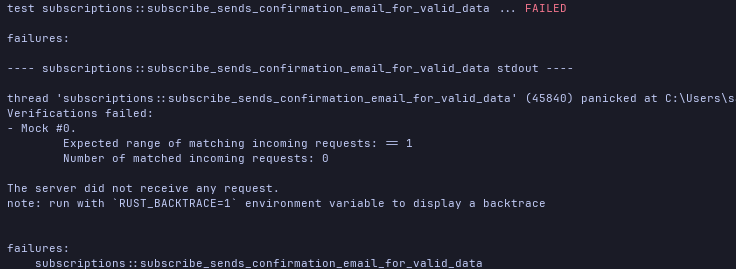

Notice that, on failure, `wiremock` gives us a detailed breakdown of what happened: we expected an incoming request, we received none.<br>
Let's fix that.

#### 7.7.1.1. Green test

Our handler looks like this right now:

```Rust
//! src/routes/subscriptions.rs
// [...]

#[tracing::instrument([...])]
pub async fn subscribe(
    form: web::Form<FormData>, pool: web::Data<PgPool>
) -> HttpResponse {
    let new_subscriber = match form.0.try_into() {
        Ok(form) => form,
        Err(_) => return HttpResponse::BadRequest().finish(),
    };
    match insert_subscriber(&pool, &new_subscriber).await {
        Ok(_) => HttpResponse::Ok().finish(),
        Err(_) => HttpResponse::InternalServerError().finish(),
    }
}
```

To send an email we need to get our hands on an instance of `EmailClient`.<br> 
As part of the work we did when writing the module, we also registered it in the application context:

```Rust
//! src/startup.rs
// [...]

fn run([...]) -> Result<Server, std::io::Error> {
    // [...]
    let email_client = Data::new(email_client);
    let server = HttpServer::new(move || {
       App::new()
            .wrap(TracingLogger::default())
            // [...]
            // Here!
            .app_data(email_client.clone())
    })
    .listen(listener)
    .run();

    Ok(server)
}
```

We can therefore access it in our handler using `web::Data`, just like we did for `pool`

```Rust
//! src/routes/subscriptions.rs
// New import!
use crate::email_client::EmailClient;
// [...]

#[tracing::instrument(
    name="Add a new subscriber"
    skip(form, pool, email_client),
    fields(
        subscriber_email = %form.email,
        subscriber_name = %form.name
    )
)]
pub async fn subscribe(
    form: web::Form<FormData>,
    pool: web::Data<PgPool>,
    // Getting the email_client from the app context
    email_client: web::Data<EmailClient>,
) -> HttpResponse {
    // [...]
    
    // refactored for early return if error
    if insert_subscriber(&pool, &new_subscriber).await.is_error(){
        return HttpResponse::InternalServerError().finish();
    }

    // Send a (useless) email to the new subscriber
    // We are ignoring email delivery errors for now.
    if email_client
        .send_email(
            new_subscriber.email,
            "Welcome!",
            "Welcome to our newslettter!",
            "Welcome to our newslettter!",
        )
        .await
        .is_err()
    {
        return HttpResponse::InternalServerError().finish();
    }

    HttpResponse::Ok().finish()
}
```

`subscribe_sends_confirmation_email_for_valid_data` now passes, but `subscribe_returns_a_200_for_valid_form_data` fails:

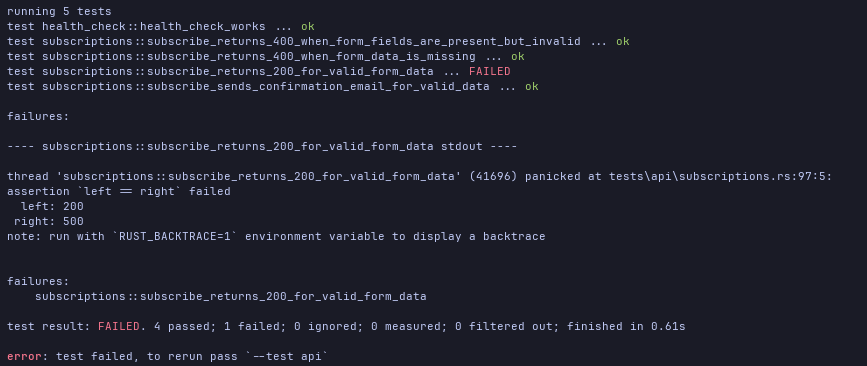

It is trying to send an email but it is failing because we haven't setup a mock in that test. Let's fix it:

```Rust
#[tokio::test]
async fn subscribe_returns_a_200_for_valid_form_data() {
    // Arrange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    // New section for email_server mock
    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .mount(&app.email_server)
        .await;
    
    // Act
    let response = app.post_subscriptions(body.into()).await;

    // Assert
    assert_eq(200, response.status().as_u16);

    // [...]
}
```

All good, the test passes now.<br>
There is not much to refactor at the moment, let's press forward.

### 7.7.2. A Static Confirmation Link

Let's raise the bar a bit <span>&mdash;</span> we will scan the body of the email to retrieve a confirmation link.

#### 7.7.2.1. Red Test

We don't care (yet) about the link being dynamic or actually meaningful <span>&mdash;</span> we just want to be sure that there is _something_
in the body that looks like a link.<br>
We should also have the same link in both the plain text and the HTML version of the email body.

How do we get the body of a request intercepted by `wiremock::MockServer`?<br>
We can use its `received_requests` method <span>&mdash;</span> it returns a vector of all the requests intercepted by the server as long as request
recording was enabled(the default)

```Rust
//! tests/api/subscriptions.rs
// [...]

#[tokio::test]
async fn subscribe_sends_a_confirmation_email_with_a_link() {
    // Arrange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        // We are not setting an expectation here anymore
        // The test is focused on another aspect of the app
        // behavior
        .mount(&app.email_server)
        .await;

    // Act
    app.post_subscriptions(body.into()).await;

    // Assert
    // Get the first intercepted request
    let email_request = &app.email_server.received_request().await.unwrap()[0];
    // Parse the body as JSON, starting from raw bytes
    let body: serde_json::Value = serde_json::from_slice(&email_request.body)
        .unwrap();
}
```

We now need to extract links out of it.<br>
The most obvious way forward would be a regular expression. Let's face it though: regexes are a messy business and it takes a while to get them right.<br>
Once again, we can leverage the work done by the larger Rust ecosystem <span>&mdash;</span>  let's add `linkify` as a development dependency:
```Toml
#! Cargo.toml
# [...]
[dev-dependencies]
linkify = "o.11.0" # Update this
# [...]
```
or 
```bash
cargo add --dev linkify
```

We can now use `linkify` to scan text and return an iterator of extracted links.

```Rust
//! tests/api/subscriptions.rs
// [...]

#[tokio::test]
async fn subscribe_sends_a_confirmation_email_with_links() {
    // [...]
    let body: serde_json::Value = serde_json::from_slice(&email_request.body)
        .unwrap();
    // Definie a closure that extracts a link given a string
    let get_link = |s: &str| {
        let links: Vec<_> = linkify::LinkFinder::new()
            .links(s)
            .filter(|l| *l.kind() == linkify::LinkKind::Url)
            .collect()
            assert_eq!(links.len(), 1);
        link[0].as_str().to_owned()
    };

    let html_link = get_link(&body["HtmlBody"].as_str().unwrap());
    let body_link = get_link(&body["HtmlBody"].as_str().unwrap());

    // The two links should be identical
    assert_eq!(html_link, text_link);
}
```

If we run the test suite, we should see the new test case failing:

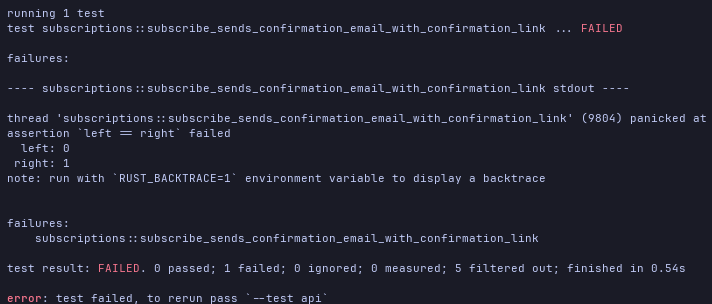

#### 7.7.2.2. Green Test

We need to tweak our request handler again to satisfy the new test case:

```Rust
//! src/routes/subscriptions.rs
// [...]

#[tracing::instrument([...])]
pub async fn subscribe(/**/) -> HttpResponse {
    // [...]
    let confrimation_link = "https://placeholder-example-domain.com/subscriptions/confirm";

    if email_client
        .send_email(
            new_subscriber.email,
            "Welcome!",
            &format!(
                "Welcome to our newsletter!<br />\
                Click <a href=\"{}\">here</a> to confirm your subscription.",
                confirmation_link
            ),
            &format!(
                "Welcome to our newsletter! Visit {} to confirm your subscription.",
                confirmation_link
            ),
        )
        .await
        .is_error()
    {
        return HttpResponse::InternalServerError().finish();
    }

    HttpResponse::Ok().finish()
}
```

the test should pass straight away.

#### 7.7.2.3. Refactor Test

Our request handler is getting a bit busy <span>&mdash;</span> there is a lot of code dealing with our confirmation email now.<br>
Let's extract it into a separate function:
```Rust
//! src/routs/subscriptions.rs
// [...]

#[tracing::instrument([...])]
pub async fn subscribe(/* */) -> HttpResponse {
    let new_subscriber = match form.0.try_into() {
        Ok(form) => form,
        Err(_) => return HttpResponse::BadRequest().finish(),
    };

    if insert_subscriber(&pool, &new_subscriber).await.is_err() {
        return HttpResponse::InternalServerError().finish();
    }

    if send_confrimation_email(&email_client, new_subscriber)
        .await
        .is_err()
    {
        return HttpResponse::InternalServerError().finish();
    }

    HttpResponse::Ok().finish()
}


#[tracing::instrument(
    name="Send a confirmation email to a new subscriber",
    skip(email_client, new_subscriber)
)]
pub async fn send_confirmation_email(
    email_client: &EmailClient,
    new_subscriber: NewSubscriber,
) -> Result<(), reqwest::Error> {
    let confirmation_link = "https://placeholder-example-domain.com/subscriptions/confirm";
    let plain_body = format!(
        "Welcome to our newsletter! Visit {} to confirm your subscription.",
        confirmation_link
    );
    let html_body = format!(
        "Welcome to our newsletter!<br />\
        Click <a href="\{}\">here</a> to confirm your subscription.",
        confirmation_link
    );

    email_client.send_email(
        new_subscriber.email,
        "Welcome!",
        &html_body,
        &plain_body,
    )
    .await
}
```

`subscribe` is once again focused on the overall flow, without bothering with details of any of its steps.

### 7.7.3. Pending Confirmation

#### 7.7.3.0. Overview

Let's look at the status for a new subscriber now.

We are currently setting their status to `confirmed` in `POST /subscriptions`, while it should be `pending_confirmation` until they click on the
confirmation link.

Time to fix it.

#### 7.7.3.1. Red Test

We can start by having a second look at our first "happy path" test.
```Rust
//! tests/api/subscriptions.rs
// [...]

#[tokio::test]
async fn subscribe_returns_a_200_for_valid_data() {
    // Arange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .mount(&app.email_server)
        .await;

    // Act
    let response = app.post_subscriptions(body.into()).await;

    // Assert
    assert_eq!(200, response.status().as_u16());

    let saved = sqlx::query("SELECT email, name FROM subscriptions",)
        .fecth_one(&app.db_pool)
        .await
        .expect("Failed to fetch saved subscription.");

    assert_eq!(saved.email, "lei_yin_loo@gmail.com");
    assert_eq!(saved.username, "lei yin");
}
```

The name is a bit of a lie <span>&mdash;</span> it is checking the status code **and** performing some assertions against the state in the database<br>
Let's split it into two separate test cases;

```Rust
#[tokio::test]
async fn subscribe_returns_200_for_valid_form_data() {
    // Arange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .mount(&app.email_server)
        .await;

    // Act
    let response = app.post_subscriptions(body.into()).await;

    // Assert
    assert_eq!(200, response.status().as_u16());

}

#[tokio::test]
async fn subscribe_persists_the_new_subscriber() {
    // Arange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .mount(&app.email_server)
        .await;

    // Act
    pp.post_subscriptions(body.into()).await;

    let saved = sqlx::query("SELECT email, name FROM subscriptions",)
        .fecth_one(&app.db_pool)
        .await
        .expect("Failed to fetch saved subscription.");

    assert_eq!(saved.email, "lei_yin_loo@gmail.com");
    assert_eq!(saved.username, "lei yin");
}
```

We can now modify the second test case to check the status as well

```Rust
#[tokio::test]
async fn subscribe_persists_the_new_subscriber() {
    // Arange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .mount(&app.email_server)
        .await;

    // Act
    pp.post_subscriptions(body.into()).await;

    let saved = sqlx::query("SELECT email, name, status, FROM subscriptions",)
        .fecth_one(&app.db_pool)
        .await
        .expect("Failed to fetch saved subscription.");

    assert_eq!(saved.email, "lei_yin_loo@gmail.com");
    assert_eq!(saved.username, "lei yin");
    assert_eq!(saved.status, "pending_confrimation");
}
```

The test fails as expected.

<span style="color: orange">--INSERT SCREENSHOT HERE--</span>

#### 7.7.3.2. Green Test

We can turn it green by touching again our insert query:
```Rust
//! src/routes/subscriptions.rs

#[tracing::instrument([...])]
pub async fn insert_subscriber([...]) -> Result<(), sqlx::Error> {
    sqlx::query!(
        r#"
            INSERT INTO subscriptions (id, email, username, subscribed_at, status)
            VALUES ($1, $2, $3, $4, 'confirmed')
        "#,
        // [...]
    )
    // [...]
}
```

We just need to change `confrimed` into `pending_confirmation`:
```Rust
//! src/routes/subscriptions.rs

#[tracing::instrument([...])]
pub async fn insert_subscriber([...]) -> Result<(), sqlx::Error> {
    sqlx::query!(
        r#"
            INSERT INTO subscriptions (id, email, username, subscribed_at, status)
            VALUES ($1, $2, $3, $4, 'pending_confirmation')
        "#,
        // [...]
    )
    // [...]
}
```

Test should be green.

### 7.7.4. Skeleton of `GET /subscriptions/confirm`

#### 7.7.4.0. Overview

We have done most of the groundwork on `POST /subscriptions` <span>&mdash;</span> time to shift our focus to the other half of the journey,
`GET /subscriptions/confirm`.<br>
We want to build up on the skeleton of the endpoint <span>&mdash;</span> we need to register the handler against the path in `src/startup.rs`
and reject incoming requests without the required query parameter, `subscription_token`. This will allows us to then build the happy path
without having to write a massive amount of code all at once $\textemdash$ baby steps!.

#### 7.7.4.1. Red Test

Let's add a new module to our `tests` project to host all our test cases dealing with the confirmation callback.

```Rust
//! tests/api/main.rs

mod health_check;
mod helpers;
mod subscriptions;
// New module
mod subscriptions_confirm;


//! tests/api/subscriptions_confirm.rs

#[tokio::test]
async fn confirmations_without_tokens_are_rejected_with_404() {
    // Arrange
    let app = spawn_app().await;

    // Act
    let response = reqwest::get(format("{}/subscriptions/confirm", app.address))
        .await
        .unwrap();

    // Assert
    assert_eq!(response.status().as_u16(), 400);
}
```

Which fails as expected, given that we have no handler yet: <br>
<span style="color: orange; font-weight: bold;">--INSERT SCREEHSHOT HERE--</span>

#### 7.7.4.2. Green Test

Let's start with a dummy handler that returns `200 OK` regardless of the incoming request:
```Rust
//! src/routes/mod.rs

mod health_check;
mod subscriptions;
// New module
mod subscriptions_confirm;

pub use health_check::*;
pub use subscriptions::*;
pub use subscriptions_confirm::*;

//! src/routes/subscriptions_confirm.rs

use actix_web::HttpResponse;

#[tracing::instrument(
    name="Confirm a pending subscriber",
)]
pub async fn confirm() -> HttpResponse {
    HttpResponse::Ok().finish()
}

//! src/startup.rs
// [...]
use crate::routes;;confirm;

fn run([...]) -> Result<Server, std::io::Error> {
    // [...]
    let server = HttpServer::new(move || {
        App::new()
        // [...]
        .route("/subscriptions/confirm", web::get().to(confirm))
        // [...]
    })
    // [...]
}
```

We would get a different error now when running `cargo test`:<br>
<span style="color: orange; font-weight: bold;">--INSERT SCREENSHOT HERE-- </span>

It worked!<br/>
Time to turn that `200 OK` into a `400 Bad Request`.<br/>
We want to ensure that there is a `subscription_token` query parameter: we can rely on another one of `acitx-web`'s extractors $\textemdash$ `Query`

```Rust
//! src/routes/subscriptions_confirm.rs
use actix_web::{HttpResponse, web};

#[derive(serde::Deserialize)]
pub struct Parameters {
    subscription_token: String
}

#[tracing::instrument(
    name="Confirm a pending subscriber",
    skip(_parameters)
)]
pub async fn confirm(_parameters: web::Query<Parameters>) -> HttpResponse {
    HttpResponse::Ok().finish()
}
```

The `Parameters` struct defines all the query parameters that we _expect_ to see in the incoming request. It needs to implement `serde::Deserialize` 
to enable `actix-web` to build it from the incoming request path. It is enough to add a function paramater of type `web::Query<Parameterss>` to
`confirm` to instruct `actix-web` to only call the handler if the extraction was successful. If the extraction failed a `400 Bad Request` is 
automatically returned to the caller.

Our tests now pass.

### 7.7.5. Connecting The Dots

#### 7.7.5.1. Red Test

Now that we have a `GET /subscriptions/confirm` handler we can try perform the full journey!

We will behave like a user: we will call `POST /subscriptions`, we will extract the confirmation link from the outgoing email request (using the `linkify` 
machinery we already built) and then call it to confirm our subscription $\textemdash$ expecting a `200 OK`<br/>
We will not be checking the `status` from the database (yet) $\textemdash$ that is going to be our grand finale.

Let's write it down.

```Rust
//! tests/api/subscriptions_confirm.rs
// [...]

use reqwest::Url;
use wiremock::{ResponseTemplate, Mock};
use wiremock::matchers::{path, method};

#[tokio::test]
async fn the_link_returned_by_subscribe_returns_a_200_if_called() {
    // Arrange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .mount(&app.email_server)
        .await;

    app.post_subscriptions(body.into()).await;
    let email_request = &app.email_server.received_requests().await.unwrap()[0];
    let body: serde_json::Value = serde_json::from_slice(&email_request.body)
        .unwrap();

    // Closure to extract link given string
    let get_link = |s: &str| {
        let links: Vec<_> = linkify::LinkFinder::new()
            .links(s)
            .filter(|l| *l.kind() == linkify::LinkKind::Url)
            .collect();
        assert_eq!(links.len(), 1);
        links[0].as_str().to_owned()
    };
    let raw_confirmation_link = &get_link(&body["HtmlBody"].as_str().unwrap());
    let confirmation_link = Url::parse(raw_confirmation_link).unwrap();
    // Let's make sure we don't call random APIs on the web
    assert_eq!(confirmation_link.host_str().unwrap(), "127.0.0.1");

    // Act
    let response = reqwest::get(confirmation_link)
        .await
        .unwrap();

    // Assert
    assert_eq!(response.status().as_u16(), 200);
}
```

It fails with<br/>
<span style="color: orange; font-weight: bold;">--INSERT SCREENSHOT HERE --</span>

There is a fair amout of code duplication going on here, but we will take care of it in due time.<br/>
Our primary focus is getting the tests to pass now.

#### 7.7.5.2. Green Test

Let's begin by taking care of the URL issue.<br/>
Its currently hard-coded in
```Rust
//! src/routes/subscriptions.rs
// [...]

#[tracing::instrument([...])]
pub async fn send_confirmation_email([...]) -> Result<(), reqwest::Error> {
    let confirmation_link = "https://placeholder-example-domain.com/subscriptions/confirm";
    // [...]
}
```
The domain and the protocal are going to vary according to the environment the application is running in: it will be `httt://127.0.0.1` for our tests,
it should be a proper DNS record with HTTPS when our applicaton is running in production.<br/>
The easiest way to get it right is to pass the domain in as a configurable value.
Let's add a new field to `ApplicationSettings`:
```Rust
//! src/configuration.rs
// [...]

#[derive(serde::Deserialize, Clone)]
pub struct ApplicationSettings {
    #[serde(deserialize_with = "deserialize_number_from_string")]
    pub port: u16,
    pub host: String,
    // New field!
    pub base_url: String
}

```
```Yaml
# configuration/local.yaml
application:
    base_url: "http://127.0.0.1"
# [...]
```

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: 2px solid white;">

**Note**:

For our fly.io deployment remember to our config will look a little different.

</div>

We now need to register the value in the application context $\textemdash$ we should be familiar with the process at this point
```Rust
//! src/startup.rs
// [...]

impl Application {
    pub async fn build(configuration: Settings) -> Result<Self, std::io::Error> {
        // [...]
        let server = run (
            listener,
            connection_pool,
            email_client,
            // New parameter!
            configuration.application.base_url,
        )?;

        Ok(Self { port, server })
    }
    // [...]
}

// We need to define a wrapper type in order to retrieve the URL
// in the `subscribe` handler.
// Retrieval from the context, in actix-web is type-based: using
// a raw `String` would expose us to conflicts.
pub struct ApplicationBaseUrl(pub String);

fn run(
    listener: TcpListener,
    db_pool: PgPool,
    email_client: EmailClient,
    // New param!
    base_url: String,
) -> Result<Server, std::io::Error> {
    // [...]
    let base_url = Data::new(ApplicationBaseUrl(base_url));
    let server = HttpServer::new( move || {
        App::new()
        // [...]
        .app_data(base_url.clone())
    })
    // [...]
}
```

We can now access it in the request handler:

```Rust
//! src/routes/subscriptions.rs
use crate::startup::ApplicationBaseUrl;
// [...]

#[tracing::instrument(
    skip(form, pool, email_client, base_url),
    [...]
)]
pub async fn subscribe(
    // [...]
    // New parameter!
    base_url: web::Data<ApplicationBaseUrl>,
) -> HttpResponse {
    // [...]
    // Passing the application url
    if send_confirmation_email(
        &email_client,
        new_subscriber,
        &base_url.0
    )
    .await
    .is_err()
    {
        return HttpResponse::InternalServerError().finish();
    }
    // [...]
}

#[tracing::instrument(
    skip(email_client, new_subscriber, base_url)
    [...]
)]
pub async fn send_confrimation_email(
    // [...]
    // New param
    base_url: &str,
) -> Result<(), reqwest::Error> {
    // Build a confirmation link with a dynamic root
    let confirmation_link = format!("{}/subscriptions/confirm", base_url);
    // [...]
}
```

Let's run the test suite again;<br/>
<span style="color: orange; font-weight: bold">--INSERT SCREENSHOT HERE--</span>

The host is correct, but `reqwest::Client` in our test is failing to establish a connection. What is going wrong?<br/>
If we look closely, we'll notice `port: None,` $\textendash$ we are sending our request to `http:://127.0.0.1/subscriptions/confirm` without
specifying the port our test server is listenering on.

The tricky bit, here, is the sequence of events: we pass in the `application_url` configuration value _before_ spinning up the server, therefore
we do not know what port it is going to listen to (given that the port is randomised using $0$!)<br/>
This is a non-issue for production workloads where the DNS domain is enough $\textemdash$ we'll just patch it in the test.<br/>
Let's store the application port in its own field within `TestApp`:
```Rust
//! tests/api/helpers.rs
// [...]

pub struct TestApp {
    // New field!
    pub port: u16,
    // [...]
}

pub async fn spawn_app() -> TestApp {
    // [...]
    let application = Application::build(configuration.clone())
        .await
        .expect("Failed to build application");
    let application_port = application.port();
    let _ = tokio::spawn(application.run_until_stopped());

    TestApp {
        address: format!("http://localhost:{}", application_port),
        port: application_port,
        db_pool: get_connection_pool(&configuration.db),
        email_server,
    }
}
```

We can then use it in the test logic to edit the confirmatin link:
```Rust
//! tests/api/subscriptions_confirm.rs
// [...]

#[tokio::test]
async fn link_returned_by_subscribe_returns_a_200_if_called () {
    // [...]
    let mut confirmation_link = Url::parse(raw_confirmation_link).unwarp();
    assert_eq!(confirmation_link.host.as_str().unwrap(), "127.0.0.1");
    // Let's rewrite the URL to include the port
    confirmation_link.set_port(Some(app.port)).unwrap();
    
    // [...]
}
```

Not the prettiest, but it gets the job done.<br/>
Let's run the test again. <br/>
<span style="color: orange; font-weight: bold;">-- INSERT SCREENSHOT HERE --</span>

We get a `400 Bad Request` back because our confirmation link does not have a `subscription_token` query parameter attached.<br/>
Let's fix it by hard-coding one for the time being.
```Rust
//! src/routes/subscriptions.rs
// [...]

pub async fn send_confirmation_email([...]) -> Result<(), reqwest::Error> {
    let confirmation_link = format!("{}/subscriptions/confirm?subscriptin_token=myToken", base_url);
    // [...]
}
```

The test passes!

#### 7.7.6.3. Refactor

The logic to extract the two confirmation links for the outgoing email request is duplicated across two of our tests $\textemdash$ we will likely add
more that rely on it as we flesh out the remaining bits and pieces of this feature.<br/>
It makes sense to extract it in its own helper function.
```Rust
//! tests/api/helpers.rs
// [...]

/// Confirmation links embedded in the request to the email API.
pub struct ConfirmationLinks {
    pub html: reqwest::Url,
    pub plain_txt: reqwest::Url
}

impl TestApp {
    // [...]

    /// Extract the confirmation links embedded in the request to the email API.
    pub fn get_confirmation_links(
        &self,
        email_request: &wiremock::Request
    ) -> ConfirmationLinks {
        let body: serde_json::Value = serde_json::from_slice(&email_request.body).unwrap();

       // Extract the link given a string
        let get_link = |s: &str| {
            let links: Vec<_> = linkify::LinkFinder::new()
                .links(s)
                .filter(|l| *l.kind() == linkify::LinkKind::Url)
                .collect();
            assert_eq!(link.len(), 1);
            let raw_link = links[0].as_str().to_owned();
            let mut confirmation_link = request::Url::parse(&raw_link).unwrap();
            confirmation_link.set_port(Some(self.port)).unwrap();
            confirmation_link
        };

        // Call closure on the request fields
        let html = get_link(&body["HtmlBody"].as_str().unwrap());
        let plain_txt = get_link(&body["TextBody"].as_str().unwrap());
        ConfirmationLinks { html, plain_txt }
    }
}
```

We are adding it as a method on `TestApp` in order to get access to the application port, which we need to inject into the links.<br/>
It could as well have been a free function taking both `wiremock::Request` and `TestApp`(or `u16`) as parameters $\textemdash$ a matter of taste.

We can now massively simplify our two test cases.
```Rust
//! tests/api/subscriptions.rs
// [...]

#[tokio::test]
async fn subscribe_sends_confirmation_email_with_a_link() {
    // Arrange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_witn(ResponseTemplate::new(200))
        .mount(&app.email_server)
        .await;

    // Act
    app.post_subscriptions(body.into()).await;

    // Assert
    let email_request = &app.email_server.received_requests().await.unwrap()[0];
    let confirmation_links = app.get_confirmation_links(&email_request);

    // The two links should be identicall
    assert_eq!(confirmation_links.html, confirmation_link.plain_txt);
}

#[tokio::test]
async fn link_returned_by_subscriber_returns_200_if_called() {
    // Arrange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .mount(&app.email_server)
        .await;

    app.post_subscriptions(body.into()).await;
    let email_request = &app.email_server.received_request().await.unwrap()[0];
    let confirmation_link = app.get_confirmation_links(&email_request);

    // Act
    let response = reqwest::get(confirmation_links.html)
        .await
        .unwrap();

    // Assert
    assert_eq!(response.status().as_u16(), 200);
}
```

The intent of the two test cases is now much clearer.

### 7.7.6. Subscription Tokens

We are now ready to tackle the elephant in the room: we need to start generating subscription tokens

#### 7.7.6.1. Red Test

We will add a new test case which builds on top of the work we just did: instead of asserting against the returned status code we will
check the `status` of the subscriber stored in the database
```Rust
//! tests/api/subscriptions_confirm.rs
// [...]

#[tokio::test]
async fn clicking_on_confirmation_link_confirms_subscriber() {
    // Arrange
    let app = spawn_app().await;
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .mount(&app.email_serrver)
        .await;

    app.post_subscriptions(body.into()).await;
    let email_request = &app.email_server.received_request().await.unwrap()[0];
    let confirmation_link = app.get_confirmation_links(&email_request);

    // Act
    reqwest::get(confirmation_link.html)
        .await
        .unwrap()
        .error_for_status()
        .unwarp();

    // Assert
    let saved = sqlx::query!("SELECT email, name, status FROM subscriptions",)
        .fetch_one(&app.db_pool)
        .await
        .expect("Failed to fetch saved subscription.");

    assert_eq!(saved.email, "lei_yin_loo@gmail.com");
    assert_eq!(saved.username, "lei yin");
    assert_eq!(saved.status, "confirmed");
}
```
The test fails, as expected.<br/>
<span style="color: orange; font-weight: bold">--INSERT SCREENSHOT HERE--</span>

#### 7.7.6.2. Green Test

To get the previous test case to pass, we hard-coded a subscription token in the confirmation link
```Rust
//! src/routes/subscriptions.rs
// [...]

pub async fn send_confirmation_email([...]) -> Result<(), reqwest::Error> {
    let confirmation_link = format!(
        "{}/subscriptions/confirm?subscription_token=myToken",
        base_url
    );
    // [...]
}
```
Let's refactor `send_confirmation_email` to take the token as a parameter $\textemdash$ it will make it easier to add the generation
logic upstream.
```Rust
//! src/routes/subscriptions.rs
// [...]

#[tracing::instrument([...])]
pub async fn subscribe([...]) -> HttpResponse {
    // [...]
    if send_confirmation_email(
        &email_client,
        new_subscriber,
        &base_url.0,
        // New parameter!
        "myToken"
    )
    .await
    .is_err()
    {
        return HttpResponse::InternalServerError().finish();
    }
    // [...]
}

#[tracing::instrument(
    name = "Send a confirmation email to a new subscriber",
    skip(email_client, new_subscriber, base_url, subscription_token)
)]
pub async fn send_confirmation_email(
    email_client: &EmailClient,
    new_subscriber: NewSubscriber,
    base_url: &str,
    // New parameter!
    subscription_token: &str
) -> Result<(), reqwest::Error> {
    let confirmation_link = format!(
        "{}/subscriptions/confirm?subscription_token={}",
        base_url,
        subscription_token
    );
    // [...]
}
```

Our subscription tokens are not passwords: they are single-use and they do not grant access to protected information. We need them to be hard enough
to guess while keeping in mind that the worst-case scenario is an unwanted newsletter subscriptions landing in someone's inbox.

Given our requirements it should be enough to use a _cryptographically secure pseudo-random number generator_ $\textendash$ a _**CSPRNG**_ if you're
into obscure acronyms.<br/>
Every time we need to generate a subscription token we can sample a sufficiently-long sequence of alphanumeric characters.

To pull it off we need to add `rand` as a dependency:
```Toml
# Cargo.toml
# [...]

[dependencies]
# [...]
# We need the `std_rng` to get access to the `PRNG` we want
rand = { version = "update-to-current-version", features=["std_rng"] }
```

```Rust
//! src/routes/subscriptions.rs
use rand::distributions::Alphanumeric;
use rand::{thread_rng, Rng};
// [...]

/// Generate a random 25-characters-long case-sensitive subscription token.
fn generate_subscription_token() -> String {
    let mut rng = thread_rng();
    std::iter::repeat_with(|| rng.sample(Alphanumeric))
        .map(char::from)
        .take(25)
        .collect()
}
```

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px">

_**NOTE:**_

Above `rand` implementation probably needs to be updated since the API has been updated quite a bit.

</div>

Using 25 characters wer roughtly get ~$10^45$ possible tokens $\textemdash$ it should be more than enough for our use case. To check if a token is valid in
`GET /subscriptions/confirm` we need `POST /subscriptions` to store the newly minted token in the database.<br/>
The table we added for this purpose, `subscription_tokens`, has two columns: `subscription_token` and `subscriber_id`.

We are currently generating the subscriber identifier in `insert_subscriber` but we never return it to the caller:
```Rust
#[tracing:instrument([...])]
pub async fn insert_subscriber([...]) -> Result<(), sqlx::Error> {
    sqlx::query!(
        r#"[...]"#,
        // The subscriber id, never returned or bound to a variable
        Uuid::now_v7(),
        // [...]
    )
    // [...]
}
```

Let's refactor `insert_subscriber` to give us back the identifier:
```Rust
#[tracing::instrument([...])]
pub async fn insert_subscriber([...]) -> Result<Uuid, sqlx::Error> {
    let subscriber_id = Uuid::now_v7();
    sqlx::query!(
        r#""#,
        subscriber_id,
        // [...]
    )
    // [...]
    Ok(subscriber_id)
}
```

We can now tie everything together:
```Rust
//! src/routes/subscriptions.rs
// [...]

pub async fn subscribe([...]) -> HttpResponse {
    // [...]
    let subscriber_id = match insert_subscriber(&pool, &new_subscriber).await {
        Ok(subscriber_id) => subscriber_id,
        Err(_) => return HttpResponse::InternalServerError().finish(),
    };
    // Add function to generate subscription token
    let subscription_token = generate_subscription_token();
    // New function to persist subscription_token to db
    if store_token(&pool, subscriber_id, &subscription_token)
        .await
        .is_err()
    {
       return HttpResponse::InternalServerError().finish(); 
    }
    if send_confirmation_email(
        &email_client,
        new_subscriber,
        &base_url.0,
        &subscription_token,
    )
    .await
    .is_err()
    {
        return HttpResponse::InternalServerError().finish();
    }
    HttpResponse::Ok().finish()
}

#[tracing::instrument(
    name = "Store subscription token in the database",
    skip(subscription_token, pool)
)]
pub async fn store_token(
    pool: &PgPool,
    subscriber_id: Uuid,
    subscription_token: &str,
) -> Result <(), sqlx::Error> {
    sqlx::query!(
        r#"
            INSERT INTO subscription_tokens (subscription_token, subscriber_id)
            VALUES ($1, $2)
        "#,
        subscription_token,
        subscriber_id,
    )
    .execute(pool)
    .await
    .map_err(|e| {
        tracing::error!("Failed to execute query: {:?}", e);
        e
    })?;
    Ok(())
}
```

We are done on `POST /subscriptions`, let's shift to `GET /subscriptions/confirm`:
```Rust
//! src/routes/subscriptions_confirm.rs

use actix_web::{HttpResponse, web};

#[derive(serde::Deserialize)]
pub struct Parameters {
    subscription_token: String
}

#[tracing::instrument(
    name = "Confirm a pending subscriber",
    skip(_ parameter)
)]
pub async fn confirm (_parameters: web::Query<Patameters>) -> HttpResponse {
    HttpResponse::Ok().finish()
}
```

We need to:
- get a reference to the database pool;
- retrieve the `subscriber_id` associated with the token (if one exists);
- change the subscriber `status` to `confirmed`.

Nothing we haven't done before $\textemdash$ let's get cracking.

```Rust
//! src/routes/subscriptions_confirm.rs

use actix_web::{web, HttpResponse};
use sqlx::PgPool;
use uuid::Uuid;

#[derive(serde::Deserialize)]
pub struct Parameters {
    subscription_token: String,
}

#[tracing::instrument(
    name = "Confirm a pending subscriber"
    skip(parameters, pool)
)]
pub async fn confirm(
    parameters: web::Query<Parameters>,
    pool: web::Data<PgPool>,
) -> HttpResponse {
    let id = matchh get_subscriber_id_from_token(
        &pool,
        &parameters.subscription_token
    ).await {
        Ok(id) => id,
        Err(_) => return HttpResponse::InternalServerError().finish(),
    };
    match id {
        // Non-existend token!
        None => HttpResponse::Unauthorized().finish(),
        Some(subscriber_id) => {
            if confirm_subscriber(&pool, subscriber_id).await.is_err() {
                return HttpResponse::InternalServerError().finish();
            }
            HttpResponse::Ok().finish()
        }
    }
}

#[rracing::instrument(
    name = "Mark Subscriber as confirmed",
    skip(subscriber_id, pool)
)]
pub async fn confirm_subscriber(
    pool: &PgPool,
    subscriber_id: Uuid
) -> Result<(), sqlx::Error> {
    sqlx::query!(
        r#"
            UPDATE subscriptions SET status = 'confirmed' WHERE id = $1
        "#
        subscriber_id,
    )
    .execute(pool)
    .await
    .map_err(|e| {
        tracing::error!("Failed to execute query: {:?}", e);
        e
    })?;
    Ok(())
}

#[trading::instrument(
    neme = "Get subscriber_id from token",
    skip(subscription_token, pool)
)]
pub async fn get_subscriber_id_from_token(
    pool: &PgPool,
    subscription_token: &str,
) -> Result<Option<Uuid>, sqlx::Error> {
    let result = sqlx::query!{
        r#"
            SELECT subscriber_id 
                FROM subscription_tokens
            WHERE subscription_token = $1
        "#,
        subscription_token,
    }
    .fetch_optional(pool)
    .await
    .map_err(|e| {
        tracing::error!(" Failed to execute query: {:?}", e);
        e
    })?;
    Ok(result.map(|r| r.subscriber_id))
}
```

Is it enough? Did we miss anything during the journey?<br/>
There is only one way to find out.
<span style="color: orange; font-weight: bold;">--INSERT SCREENSHOT HERE--</span>

Oh yes! It works!

## 7.8. Database Transactions

### 7.8.1. All Or Nothing

It is too soon to declare victory though.<br/>
Our `POST /subscriptions` handler has grown in complexity $\textemdash$ we are now performing two `INSERT` queries against our Postgres
database: one to store the details of the new subscriber, one to store the newly generated subscription token.<br/>
What happens if the application crashes between those two operations?

The first query might complete successfully, but the second one might never be executed.

There are three possible states for our database after an invocation of `POST /subscriptions`:
- a new subscriber and its token have been persisted;
- a new subscriber has been persisted, without a token;
- nothing has been persisted.

The more queries we have, the worse it gets to reason about the possible end states of our database.

Relational databases (and a few others) provide a mechanism to mitigate this issue: **transactions**.

_Transactions:_ are a way to group together related operations in a single **unit of work.**<br/>
The database guarantees that all operations within a transaction will succeed or fail together: the database will never be left in a state
where the effect of only a subset of the queries in a transactoin is visible.

Going back to our example, if we wrap the two `INSERT` queries in a transaction we now have **two** possible end states:
- a new subscriber and its token have been persisted;
- nothing has been persisted.

Much easier to deal with.

### 7.8.2. Transactions In Postgres

To start a transaction in Postgres we use a `BEGIN` statement. All queries after `BEGIN` are part of the transaction.<br/>
The transaction is then finalized with a `COMMIT` statement.

We have actually already used a transaction in one of our migration scripts!
```SQL
BEGIN;
    UPDATE subscriptions
        SET status = 'confirmed'
        WHERE status IS NULL;
    ALTER TABLE subscriptions ALTER COLUMN status SET NOT NULL;
COMMIT;
```
If any of the queries within a transaction fail the database **rolls back**; all the changes performed by previous queries are reverted,
the operation is aborted.<br/>
We can also explicitly trigger a rollback with the `ROLLBACK` statement.

Transactions are a deep topic: they not only provice a way to convert multiple statements into an all-or-nothing operation, they also hide the
effect of uncommitted changes from other queries that might be running, concurrently, against the same tables.<br/>
As our need evolves, we will often want to explicitly choose the **isolation level** of our transactions to fine-tune the concurrency guarantees
provide by the database on our operations. Getting a good grip on the different kinds of concurrency-related issues (e.g. dirty reads, phantom reads,
etc.) becomes more and more important as our system grows in scale and complexity.

_"Designing Data Intensive Applications"_ is a must read for going deeper and learning more about these topics.

### 7.8.3. Transactions in Sqlx

Back to the code: how do we leverage transactions in `sqlx`?

We don't have to manually write a `BEGIN` statement: transactions as so central to the usage of relational databases that `sqlx` provides
a dedicated API.<br/>
By calling `begin` on our `pool` we acquire a connection from the pool and kick off a transaction:
```Rust
//! src/routes/subscriptions.rs
// [...]

pub async fn subscribe([...]) -> HttpResponse {
    let new_subscriber = // [...]

    let mut transaction = match pool.begin().await {
        Ok(transaction) => transaction,
        Err(_) => return HttpResponse::InternalServerError().finish(),
    };
    // [...]
}
```

`begin`, if successful, returns a `Transaction` struct.<br/>
A mutable reference to a `Transaction` dereferences to `sqlx`'s `Connection` therefore it can be used to run queries. All queries run using a
`Transaction` as executor become part of the transaction.

Let's pass `transaction` down to `insert_subscriber` and `store_token` instead of `pool`:
```Rust
//! src/routes/subscriptions.rs
use sqlx::{Postgres, Transaction, Executor};
// [...]

#[tracing::instrument([...])]
pub async fn subscriber([...]) -> HttpResponse {
    // [...]
    let mut transaction = match pool.begin().await {
        Ok(transaction) => transaction,
        Err(_) => return HttpResponse::InternalServerError().finish(),
    };

    let subscriber_id = match insert_subscriber(
        &mut transaction,
        &new_subscriber
    ).await {
        Ok(subscriber_id) => subscriber_id,
        Err(_) => return HttpResponse::InternalServerError().finish();
    }
    // [...]
}

#[tracing::instrument(
    name = "Saving new subscriber details in the database",
    skip(new_subscriber, transaction)
)]
pub async fn insert_subscriber(
    transaction: &mut Transaction<'_, Postgres>,
    new_subscriber: &NewSubscriber,
) -> Result<Uuid, sqlx::Error> {
    let subscriber_id = Uuid::now_v7();
    let query = sqlx::query!([...]);
    transaction.execute(query)
        .await
        // [...]
    // [...]
}

#[tracing::instrument(
    name = "Store subscription token in the datbase",
    skip(subscription_token, transaction)
)]
pub async fn store_token(
    transaction: &mut Transaction<'_, Postgres>,
    subscriber_id: Uuid,
    subscription_token: &str,
) -> Result <(), sqlx::Error> {
    let query = sqlx::query!([...]);
    transaction.execute(query)
        .await
        // [...]
    // [...]
}
```

Running `cargo test` now we see something funny: some of our tests are failing!<br/>
Why is that happening?

As we discussed, a transaction has to either be committed or rolled back.<br/>
`Transaction` exposes two dedicated methods: `Transaction::commit`, to persist changes, and `Transaction::rollback`, to abort the
whole operation. <br/>
We are not calling either $\textemdash$ what happends in that case?

We can look at `sqlx`'s source code to understand better.<br/>
In particular, `Transaction`'s `Drop` implementation:
```Rust
impl<'c, DB> Drop for Transaction<'c, DB>
where
    DB: Dataase,
{
    fn drop(&mut self) {
        if self.open {
            // starts a rollback operation

            // what this does depends on the database but generally
            // this means we queue a rollback oeration that will
            // happen on the next asynchronous invocation of the 
            // underlying connection (including if the connection
            // is returned to a pool)
            DB::TransactionManager::start_rollback(&mut self.connection);
        }
    }    
}
```
`self.open` is an internal `boolean` flag attached to the connection used to begin the transaction and run the queries attached to it.<br/>
When a transaction is created, using `begin`, it is set to `true` unitl either `rollback` or `commit` are called:
```Rust
impl <'c, DB> Transaction<'c, DB>
where
    DB: Database,
{
    pub(crate) fn begin(
        conn: impl Into<MaybePoolConnection<'c, DB>>,
    ) -> BoxFoture<'c, Result<Self, Error>> {
        let mut conn = conn.into();

        Box::pin(async move  `{
            DB::TransactionManager::begin(&mut conn).await?;
            Ok(Self {
                connection: conn,
                open: true,
            })
        })
    }

    pub async fn commit(mut self) -> Result<(), Error> {
        DB::TransactionManager::commit(&mut self.connection).await?;
        self.open = false;
        Ok(())
    }

    pub async fn rollback(mut self) -> Result<(), Error> {
        DB::TransactionManager::rollback(&mut self.connection).await?;
        self.open = false;

        Ok(())
    }
}
```

In other words: if `commit` or `rollback` have not been called before the `Transaction` object goes out of scope (i.e. `Drop` is
invoked), a `rollback` command is queued to be executed as soon as the opportunity arises.

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px;">

_Footnote:_

Rust does not currently support asynchronous destructors a.k.a `AsyncDrop`. There have been some discussions on the topic, but 
there is no consensus yet.
    
</div>

That is why our tests are failing: we are using a transaction but we are not explicitly committing the changes. When the connection
goes back into the pool, at the end of our request handler, all changes are rolled back and our test expectations are not met.

We can fix it by adding a one-lineer to `subscribe`:
```Rust
//! src/routes/subscriptions.rs
use sqlx::{Postgres, Transaction};
// [...]

#[tracing::instrument[..]]
pub async fn subscribe([...]) -> HttpResponse {
    // [...]
    let mut transaction = match pool.begin().await {
        Ok(transaction) => transaction,
        Err(_) => return HttpResponse::InternalServerError().finish(),
    };
    let subscriber_id = match insert_subscriber(
        &mut transaction,
        &new_subscriber
    ).await {
        Ok(subscriber_id) => subscriber_id,
        Err(_) => return HttpResponse::InternalServerError().finish(),
    };
    let subscription_token = generate_subscription_token();
    if store_token(&mut transaction, subscriber_id, &subscription_token)
        .await
        .is_err()
    {
        return HttpResponse::InternalServerError().finish();
    }
    if transaction.commit().await.is_err() {
        return HttpResponse::InternalServerError().finish();
    }
    // [...]
}
```
The test suite should succeed once again. <br/>
Go ahead and deploy the application: seeing a feature working in a live environment adds a whole new level of satisfaction.

## 7.9. Summary

This chapter was a long journey, but we have come a long way as well!<br/>
The skeleton of our application has started to shape up, starting with our test suite. Features are moving along well: we how have
a functional subscription flow, with a proper confirmation email.<br/>
More importantly: we are getting into the **rhythm** of writing Rust code.
The very end of the chapter has been a long pair programming session where we have made significant progress _without_ introducing
new concepts.

This is a great moment to go off and explore a bit on our own. improve on what we've build so far!<br/>
There are plenty of opportunities:
- What happens if a user tries to subscribe twice? Make sure that they receive two confirmatin emails:
- What happends if a user clicks on a confirmation link twice? _Indempotent transaction?_
- What happends if the subscription token is well-formatted but non-existent? _Appropriate propagation of Error?_
- Add validation on the incoming token, we are currently passing the raw user input straighy into a query (thanks `sqlx` for
  protecting use from SQL injections 🫶);
- Use proper templating solutions for our email (e.g. `tera`);
- Anything that comes to mind!

It takes deliberate practice to achieve mastery.